# Player Engagement Analysis & Prediction

### **Overview: Predict Online Gaming Behavior**

This dataset provides a **detailed view** of player behavior and demographics in **online gaming environments**. It includes a variety of features that capture key aspects of gaming activity, player characteristics, and engagement levels, making it an excellent resource for analyzing player retention and predicting engagement patterns. 

#### **Features:**

1. **Player Demographics**:
   - **PlayerID**: Unique identifier for each player.
   - **Age**: Age of the player.
   - **Gender**: Gender of the player.
   - **Location**: Geographic location of the player.

2. **Game-Specific Attributes**:
   - **GameGenre**: Genre of the game the player is engaged in (e.g., RPG, Strategy, Action).
   - **GameDifficulty**: Difficulty level of the game, categorized as Easy, Medium, or Hard.
   - **PlayerLevel**: Current level of the player in the game.
   - **AchievementsUnlocked**: Number of achievements unlocked by the player.

3. **Engagement Metrics**:
   - **PlayTimeHours**: Average hours spent playing per session.
   - **InGamePurchases**: Indicates whether the player makes in-game purchases (0 = No, 1 = Yes).
   - **SessionsPerWeek**: Number of gaming sessions per week.
   - **AvgSessionDurationMinutes**: Average duration of each gaming session in minutes.

4. **Target Variable**:
   - **EngagementLevel**: The target variable categorizes player engagement levels into three classes: 'High', 'Medium', and 'Low', reflecting player retention and activity.

### **Data Highlights**
- The dataset includes **40,034 player entries** with **13 features**.
- Features are a mix of **numerical** and **categorical** values.
- No missing values are present. 

### **Objective**:
The primary goal is to analyze and predict player engagement levels based on their **gaming behavior**, **preferences**, and **demographics**. This analysis aims to:

1. **Identify Factors Influencing Engagement**:
   - Pinpoint the key features that drive higher engagement levels, such as session duration, player level, and frequency of gaming.

2. **Develop Predictive Models**:
   - Build machine learning models to classify players into engagement levels (Low, Medium, High) with **high accuracy** and **interpretability**.

3. **Provide Actionable Insights**:
   - Generate insights for **game developers** and **marketers** to enhance player retention and improve the overall gaming experience.

4. **Optimize Engagement Strategies**:
   - Suggest interventions, such as **tailored rewards**, **challenges**, or **personalized recommendations**, to maximize player engagement and retention.

This analysis not only helps understand player behavior but also provides a **strategic foundation** for improving **game design**, **marketg strategies**, and **player retention**. 
etg strategies**, and **player retention**. 🚀




In [33]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Load and Explore Dataset

In [34]:
# Load the dataset
df = pd.read_csv(r"E:\online_gaming_behavior\online_gaming_behavior_dataset.csv")

# Display shape of the dataset
print("Shape of the dataset:", df.shape)
display(df.head())

Shape of the dataset: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [35]:
# Display basic information
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), 

In [36]:
# Display statistical summary
print("Statistical Summary:")
display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


In [37]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

Number of duplicate rows: 0


## Unique Value Exploration

In [38]:
# Display the number of unique values in each column
unique_values = df.nunique()
print("Number of unique values in each column:")
print(unique_values)

Number of unique values in each column:
PlayerID                     40034
Age                             35
Gender                           2
Location                         4
GameGenre                        5
PlayTimeHours                40034
InGamePurchases                  2
GameDifficulty                   3
SessionsPerWeek                 20
AvgSessionDurationMinutes      170
PlayerLevel                     99
AchievementsUnlocked            50
EngagementLevel                  3
dtype: int64


In [39]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("Numerical Columns:\n", numerical_columns)
print("\nCategorical Columns:\n", non_numerical_columns)

Numerical Columns:
 ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

Categorical Columns:
 ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']


In [40]:
# Display unique values for each categorical column
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].unique()}")


Column: Gender
Unique Values: ['Male' 'Female']

Column: Location
Unique Values: ['Other' 'USA' 'Europe' 'Asia']

Column: GameGenre
Unique Values: ['Strategy' 'Sports' 'Action' 'RPG' 'Simulation']

Column: GameDifficulty
Unique Values: ['Medium' 'Easy' 'Hard']

Column: EngagementLevel
Unique Values: ['Medium' 'High' 'Low']


## Exploratory Data Analysis (EDA)

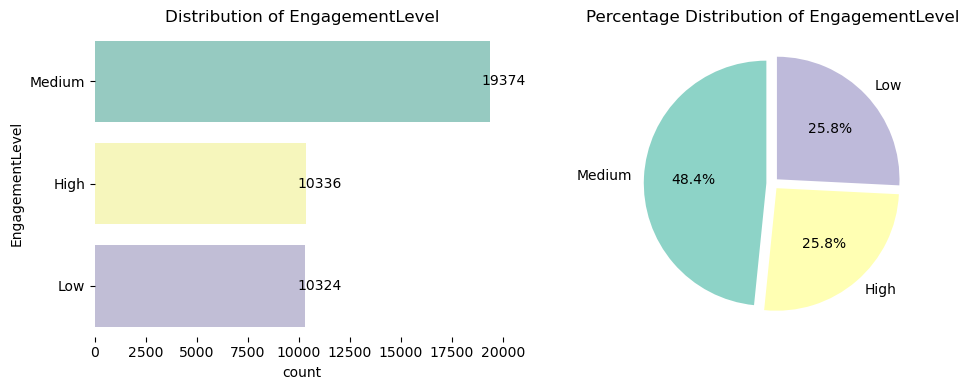

In [41]:
column_name = 'EngagementLevel'
plt.figure(figsize=(10, 4))

# First subplot: Count plot
plt.subplot(1, 2, 1)
sns.countplot(y=column_name, data=df, palette='Set3')  
plt.title(f'Distribution of {column_name}')

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', xytext=(10, 0), textcoords='offset points')

sns.despine(left=True, bottom=True)

# Second subplot: Pie chart
plt.subplot(1, 2, 2)
df[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set3'), startangle=90, explode=[0.05]*df[column_name].nunique())
plt.title(f'Percentage Distribution of {column_name}')
plt.ylabel('')  

plt.tight_layout()
plt.show()

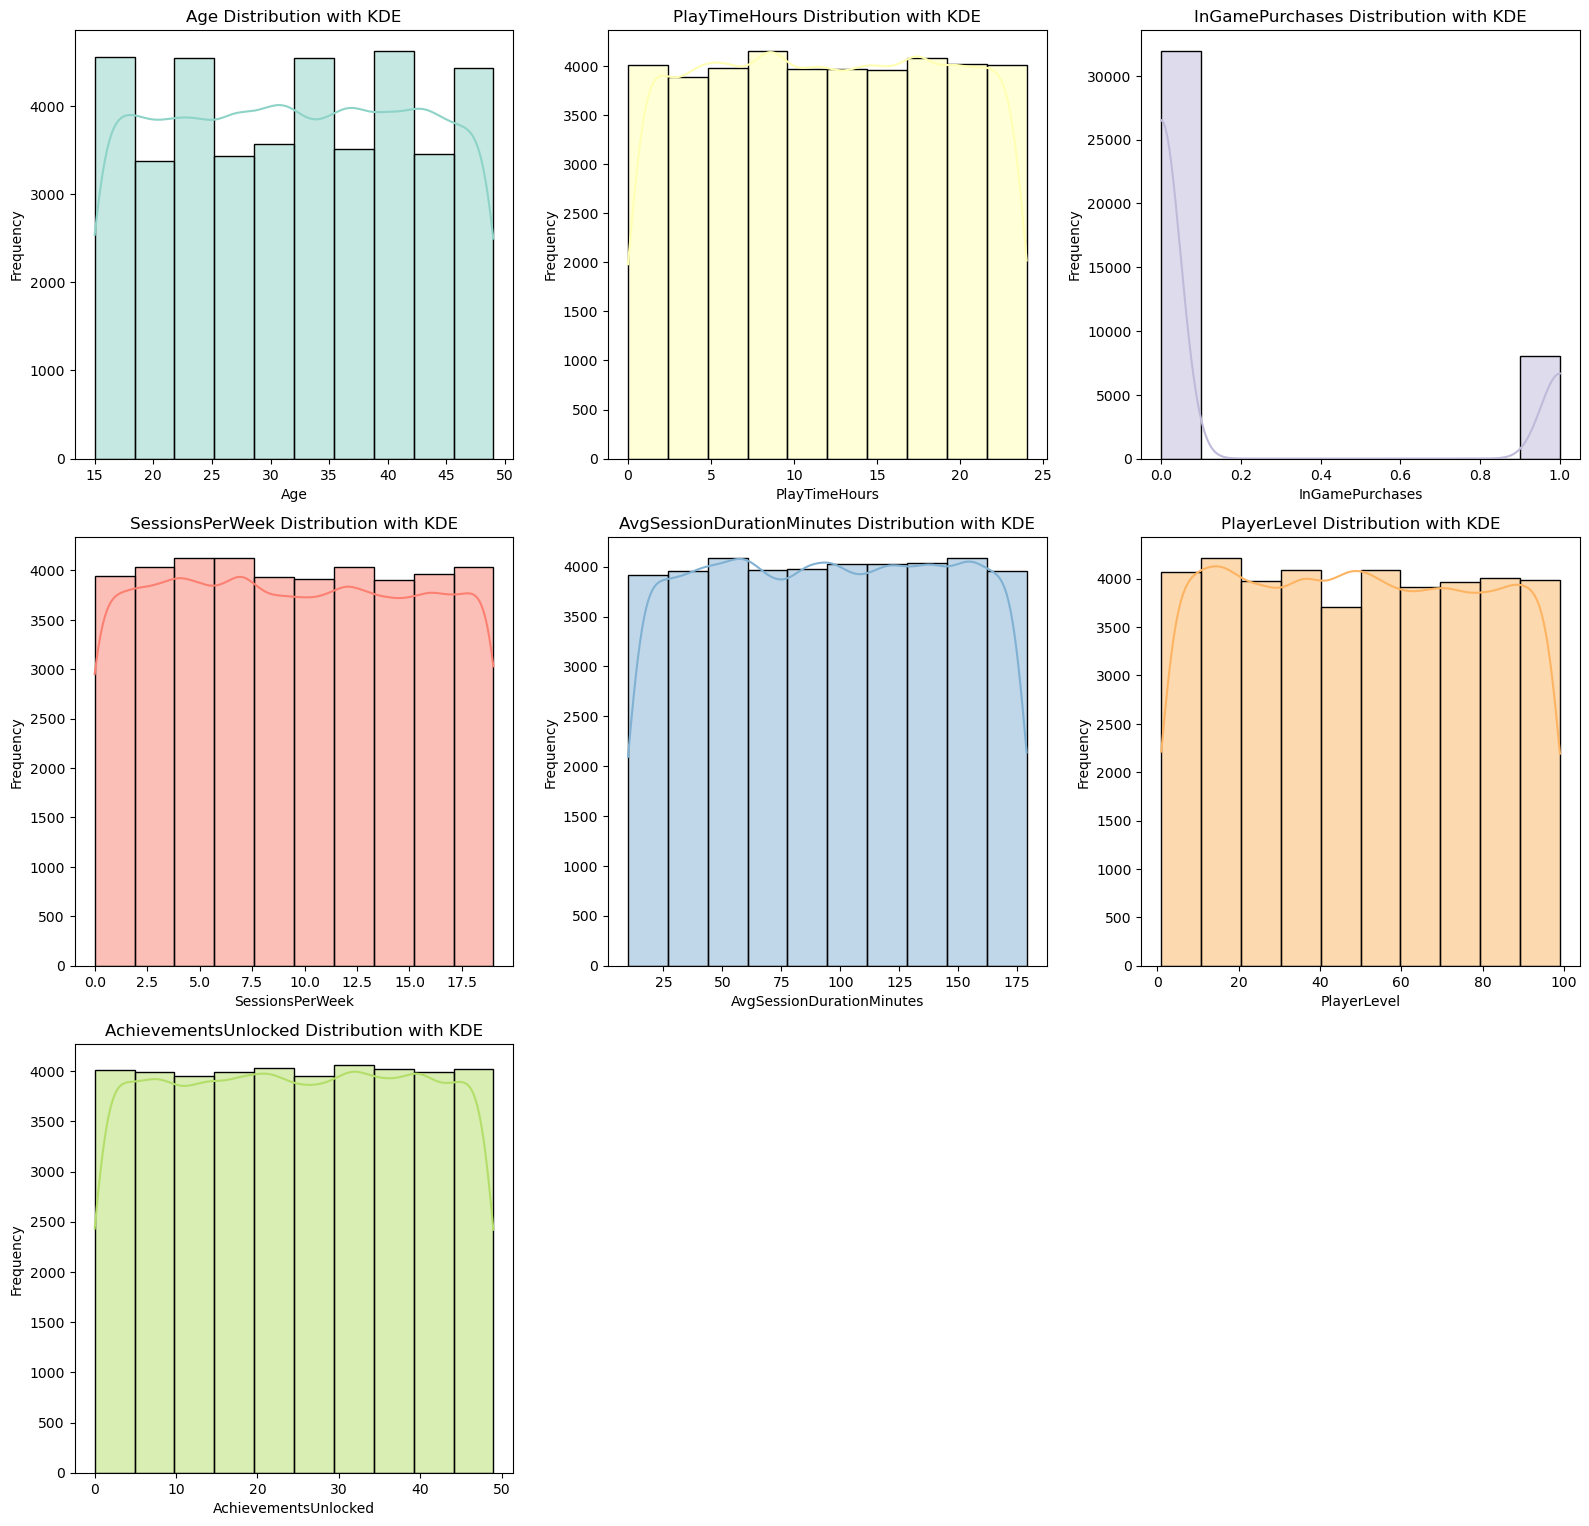

In [42]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(16, 20))  # Adjusted to accommodate more plots
    
    set3_colors = sns.color_palette("Set3", len(columns))
    
    for i, column in enumerate(columns):
        plt.subplot(4, 3, i + 1)  
        sns.histplot(data[column], kde=True, bins=10, color=set3_colors[i])
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Columns to analyze
columns_to_analyze = [
    'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 
    'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked'
]

# Perform univariate analysis
univariate_analysis(df, columns_to_analyze)

### **Insights**

1. **Age**:
   - The distribution is approximately uniform with a slight right skew, and most players fall between 20 and 40 years old.
   - The concentration around 25–30 years indicates the core player base consists of young adults.

2. **PlayTimeHours**:
   - Playtime follows a roughly uniform spread between 0–24 hours, with a mild concentration near 10–15 hours.
   - A small subset of players logs near-maximum hours, likely representing dedicated or competitive gamers.

3. **InGamePurchases**:
   - This binary feature is heavily skewed toward 0 (no purchase), with only about 20% of players making in-game purchases.
   - This reflects the typical free-to-play monetization pattern where a small "whale" segment drives revenue.

4. **SessionsPerWeek**:
   - Sessions per week are uniformly distributed between 0 and 19, with no strong peaks.
   - This even spread suggests the dataset captures a broad range of casual to hardcore players.

5. **AvgSessionDurationMinutes**:
   - Session duration is nearly uniformly distributed between 10 and 179 minutes.
   - Most players cluster around 60–120 minutes per session, which aligns with typical gaming session lengths.

6. **PlayerLevel**:
   - Player levels are uniformly spread from 1 to 99, indicating no bottleneck or clustering at specific progression stages.
   - This suggests that level progression is steady and not gated by difficulty spikes.

7. **AchievementsUnlocked**:
   - Achievements follow a roughly uniform distribution from 0 to 49.
   - The absence of sharp peaks suggests that achievement unlocking scales naturally with playtime and progression.

In [43]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Calculate skewness and kurtosis
skewness = numerical_df.skew()
kurtosis = numerical_df.kurt()

display("Skewness:", skewness)
print("\n")
display("Kurtosis:", kurtosis)

'Skewness:'

PlayerID                     0.000000
Age                         -0.004466
PlayTimeHours               -0.002225
InGamePurchases              1.493398
SessionsPerWeek              0.015517
AvgSessionDurationMinutes   -0.005632
PlayerLevel                  0.018754
AchievementsUnlocked        -0.005136
dtype: float64

'Kurtosis:'

PlayerID                    -1.200000
Age                         -1.192417
PlayTimeHours               -1.195706
InGamePurchases              0.230249
SessionsPerWeek             -1.206566
AvgSessionDurationMinutes   -1.199556
PlayerLevel                 -1.199738
AchievementsUnlocked        -1.199623
dtype: float64

### Observational Insights from Skewness and Kurtosis

#### **Skewness**


| Feature                     | Skewness     | Observation                                                                 |
|-----------------------------|--------------|-----------------------------------------------------------------------------|
| `PlayerID`                 | 0.000        | Perfectly symmetric, as it is a unique identifier.                        |
| `Age`                      | -0.004       | Very close to symmetric, no strong skewness.                              |
| `PlayTimeHours`            | -0.002       | Nearly symmetric, no skewness.                                            |
| `InGamePurchases`          | 1.493        | Positively skewed, indicating most players do not make purchases.         |
| `SessionsPerWeek`          | 0.016        | Symmetric, with no significant skewness.                                  |
| `AvgSessionDurationMinutes`| -0.006       | Symmetric, no skewness.                                                   |
| `PlayerLevel`              | 0.019        | Very symmetric, no skewness.                                              |
| `AchievementsUnlocked`     | -0.005       | Symmetric, no skewness.                                                   |

#### **Kurtosis**


| Feature                     | Kurtosis     | Observation                                                                 |
|-----------------------------|--------------|-----------------------------------------------------------------------------|
| `PlayerID`                 | -1.200       | Light-tailed, evenly distributed unique IDs.                               |
| `Age`                      | -1.192       | Light-tailed, even spread of ages.                                         |
| `PlayTimeHours`            | -1.196       | Light-tailed, most players have similar playtimes.                         |
| `InGamePurchases`          | 0.230        | Slightly heavy-tailed, some outliers due to high purchasing behavior.      |
| `SessionsPerWeek`          | -1.207       | Light-tailed, most players have consistent session frequencies.            |
| `AvgSessionDurationMinutes`| -1.200       | Light-tailed, most session durations are similar.                          |
| `PlayerLevel`              | -1.200       | Light-tailed, even distribution of player levels.                          |
| `AchievementsUnlocked`     | -1.200       | Light-tailed, most players unlock achievements at a consistent pace.       |


### Key observations:
1. **Symmetry**:
   - Most numerical features are symmetric (skewness near 0), indicating balanced distributions.

2. **Light-Tailed Behavior**:
   - Features like `Age`, `PlayTimeHours`, and `AchievementsUnlocked` have light-tailed distributions, showing consistent patterns without extreme values.

3. **Purchases Stand Out**:
   - `InGamePurchases` is positively skewed and slightly heavy-tailed, suggesting most players don't purchase, but a few outliers contribute significantly.

4. **Player Behavior**:
   - Features like `SessionsPerWeek` and `AvgSessionDurationMinutes` are symmetric and light-tailed, indicating stable engagement patterns across the player base.

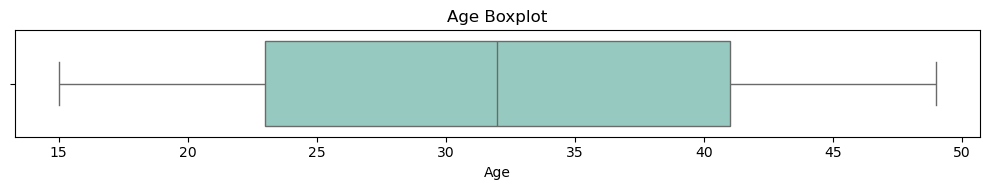


Summary Statistics for Age:
 count    40034.000000
mean        31.992531
std         10.043227
min         15.000000
25%         23.000000
50%         32.000000
75%         41.000000
max         49.000000
Name: Age, dtype: float64


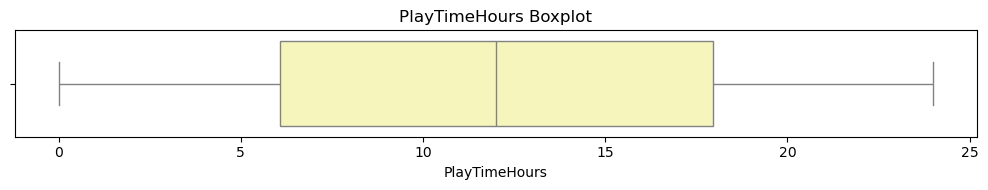


Summary Statistics for PlayTimeHours:
 count    40034.000000
mean        12.024365
std          6.914638
min          0.000115
25%          6.067501
50%         12.008002
75%         17.963831
max         23.999592
Name: PlayTimeHours, dtype: float64


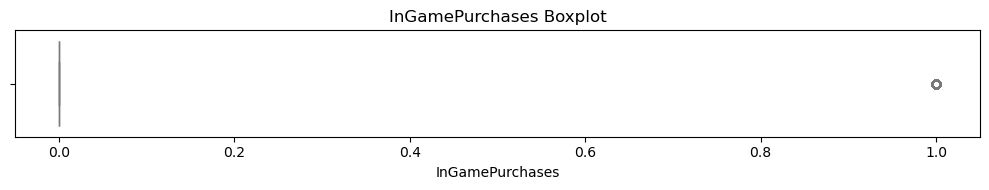


Summary Statistics for InGamePurchases:
 count    40034.000000
mean         0.200854
std          0.400644
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: InGamePurchases, dtype: float64


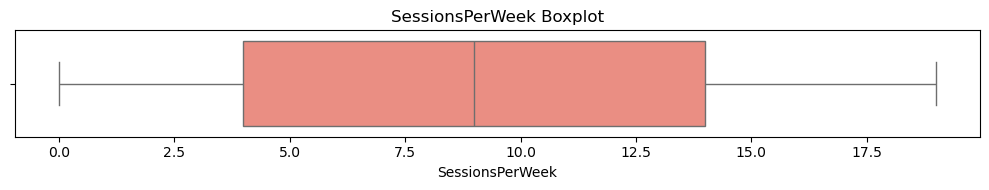


Summary Statistics for SessionsPerWeek:
 count    40034.000000
mean         9.471774
std          5.763667
min          0.000000
25%          4.000000
50%          9.000000
75%         14.000000
max         19.000000
Name: SessionsPerWeek, dtype: float64


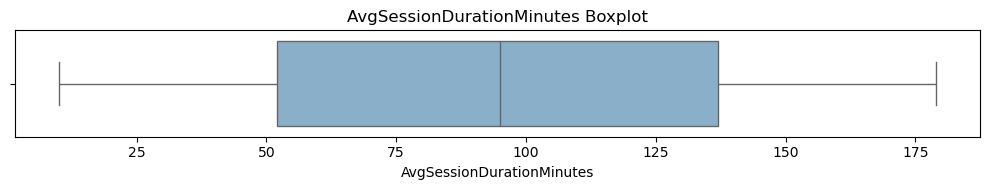


Summary Statistics for AvgSessionDurationMinutes:
 count    40034.000000
mean        94.792252
std         49.011375
min         10.000000
25%         52.000000
50%         95.000000
75%        137.000000
max        179.000000
Name: AvgSessionDurationMinutes, dtype: float64


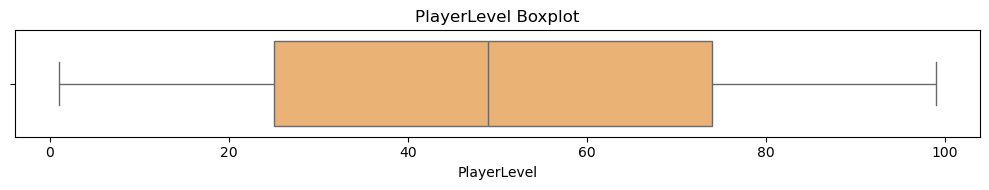


Summary Statistics for PlayerLevel:
 count    40034.000000
mean        49.655568
std         28.588379
min          1.000000
25%         25.000000
50%         49.000000
75%         74.000000
max         99.000000
Name: PlayerLevel, dtype: float64


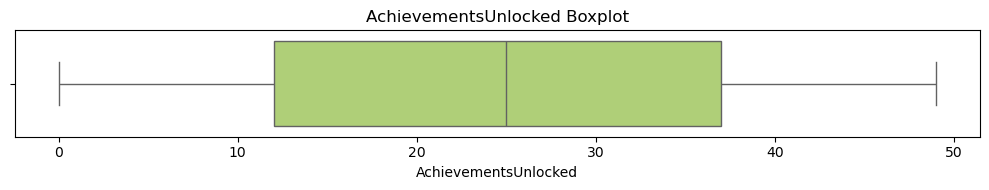


Summary Statistics for AchievementsUnlocked:
 count    40034.000000
mean        24.526477
std         14.430726
min          0.000000
25%         12.000000
50%         25.000000
75%         37.000000
max         49.000000
Name: AchievementsUnlocked, dtype: float64


In [44]:
# Function to perform univariate analysis for numeric columns with boxplots and statistics
def univariate_analysis(data, column, title):
    plt.figure(figsize=(10, 2))
    
    color = sns.color_palette("Set3")[columns_to_analyze.index(column) % len(sns.color_palette("Set3"))]
    sns.boxplot(x=data[column], color=color)
    plt.title(f'{title} Boxplot')
    plt.tight_layout()
    plt.show()

    print(f'\nSummary Statistics for {title}:\n', data[column].describe())

# Columns to analyze
columns_to_analyze = [
    'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 
    'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked'
]

for column in columns_to_analyze:
    univariate_analysis(df, column, column.replace('_', ' '))


#### **Insights and Analysis**

#### 1. **Age**
- The average age of players is approximately 32, indicating a mature audience. The age range suggests both younger and older players are engaged, which can influence game design to cater to various preferences.

**Recommendations**:
- **Game Design**: Consider incorporating features that appeal to both younger and older demographics, such as nostalgia elements for older players and fast-paced action for younger audiences.
- **Marketing Strategies**: Tailor marketing campaigns to highlight aspects of the game that resonate with different age groups, such as community aspects for older players and competitive elements for younger ones.

#### 2. **PlayTimeHours**
- Players spend an average of about 12 hours playing, with some playing significantly less (as indicated by the minimum value) and others approaching the maximum limit.

**Recommendations**:
- **Player Engagement**: Implement features that encourage longer play sessions, such as compelling storylines or rewards for extended gameplay.
- **Retention Strategies**: Identify players with low playtime and develop targeted re-engagement campaigns (e.g., special events or promotions).

#### 3. **InGamePurchases**
- A significant portion of players does not engage in in-game purchases, indicating a potential area for growth.

**Recommendations**:
- **Monetization Strategies**: Introduce incentives for in-game purchases, such as exclusive content or limited-time offers. Consider adjusting pricing strategies based on player engagement levels.
- **Player Education**: Enhance visibility of purchase options through tutorials or prompts that explain benefits without being intrusive.

#### 4. **SessionsPerWeek**
- Players engage in nearly ten sessions per week on average, suggesting a consistent level of interest.

**Recommendations**:
- **Content Updates**: Regularly update content or introduce new challenges to maintain interest and encourage more frequent sessions.
- **Community Engagement**: Foster a community around the game through forums or social media platforms where players can share experiences and tips.

#### 5. **AvgSessionDurationMinutes**
- Players spend an average of nearly an hour and a half per session, indicating strong engagement during gameplay.

**Recommendations**:
- **Session Design**: Design sessions that are engaging enough to retain players for longer periods while also providing opportunities for shorter play sessions for those with less time.
- **Feedback Mechanisms**: Implement in-game feedback tools to understand what keeps players engaged during longer sessions.

#### 6. **PlayerLevel**
- The average player level is around halfway through the maximum level, suggesting a balanced progression system that keeps players motivated.

**Recommendations**:
- **Progression Systems**: Ensure that leveling up remains rewarding by introducing meaningful rewards at various milestones.
- **Skill-Based Challenges**: Create challenges tailored to different skill levels to keep both novice and experienced players engaged.

#### 7. **AchievementsUnlocked**
- Players unlock an average of about half of the available achievements, indicating room for improvement in achievement engagement.

**Recommendations**:
- **Achievement System Optimization**: Review the achievement system to ensure it encourages exploration and diverse gameplay styles. Consider adding achievements that promote social interaction or community events.


By analyzing these metrics, can optimize game design and marketing strategies effectively while enhancing player experiences:

1. Tailor game features and marketing campaigns based on demographic insights.
2. Implement strategies that encourage engagement and retention through content updates and community building.
3. Optimize monetization approaches while ensuring that they align with player interests and behaviors.

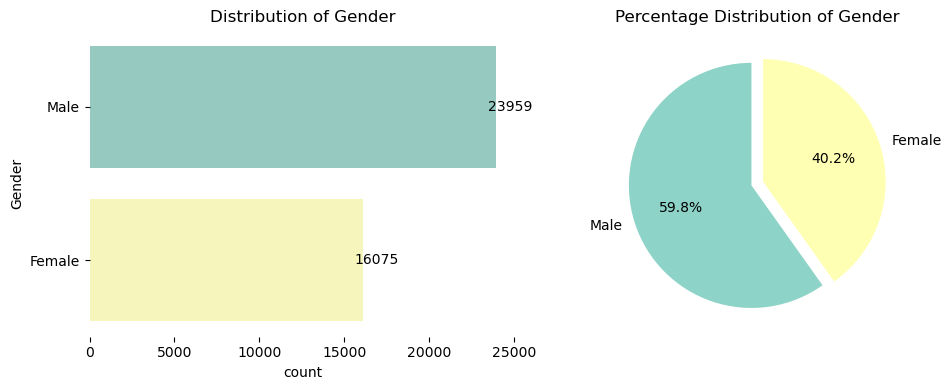

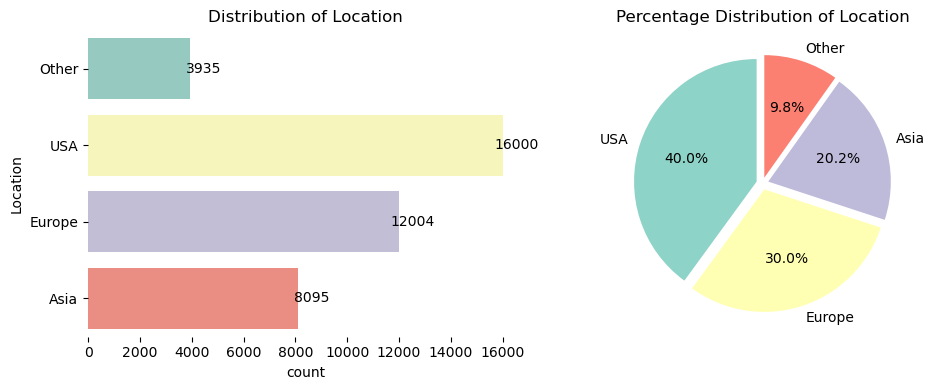

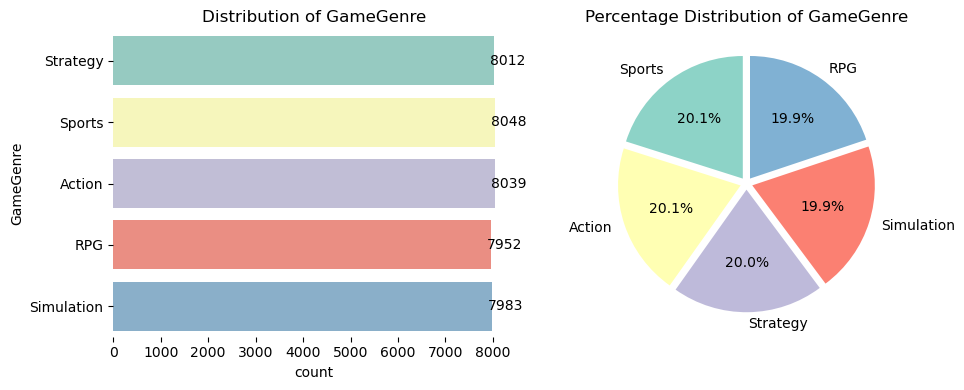

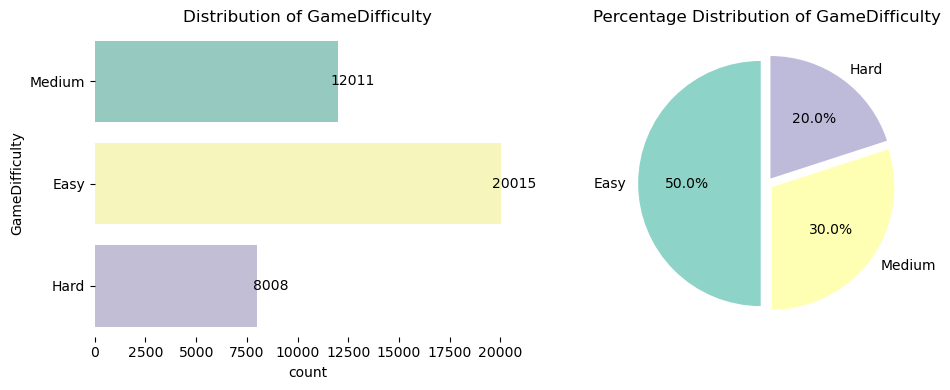

In [45]:
def plot_categorical_distribution(column_name, data=df):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.countplot(y=column_name, data=data, palette='Set3')  
    plt.title(f'Distribution of {column_name}')
    
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', xytext=(10, 0), textcoords='offset points')
    
    sns.despine(left=True, bottom=True)
    
    plt.subplot(1, 2, 2)
    data[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set3'), 
                                              startangle=90, explode=[0.05]*data[column_name].nunique())
    plt.title(f'Percentage Distribution of {column_name}')
    plt.ylabel('')  
    
    plt.tight_layout()
    plt.show()

categorical_features = ['Gender', 'Location', 'GameGenre', 'GameDifficulty']

for feature in categorical_features:
    plot_categorical_distribution(feature, df)


### **Insights from Categorical Features**

#### 1. **Gender**
- Males account for roughly 60% of the player base, while females make up about 40%. This gender gap presents an opportunity to develop more inclusive game features, marketing campaigns, and community initiatives targeted at female gamers to broaden the audience.

#### 2. **Location**
- The USA leads in player count, followed by Europe and Asia, with "Other" regions contributing a smaller share. Regional differences in gaming culture suggest that localized events, language support, and culturally relevant content could boost engagement in underrepresented markets.

#### 3. **Game Genre**
- Genres are relatively evenly distributed, with Sports and Action holding a slight edge. This balanced distribution signals that cross-genre features or hybrid game modes could attract players who enjoy multiple genres and increase overall session diversity.

#### 4. **Game Difficulty**
- About half the players prefer Easy difficulty, indicating a strong casual gaming tendency. Developers should ensure smooth onboarding and adjustable difficulty curves so that casual players stay engaged while hardcore players still find sufficient challenge.


Summary Statistics for Age by Engagement Level:
                      mean  median  count
EngagementLevel                          
High             31.920085    32.0  10336
Low              31.896939    32.0  10324
Medium           32.082120    32.0  19374


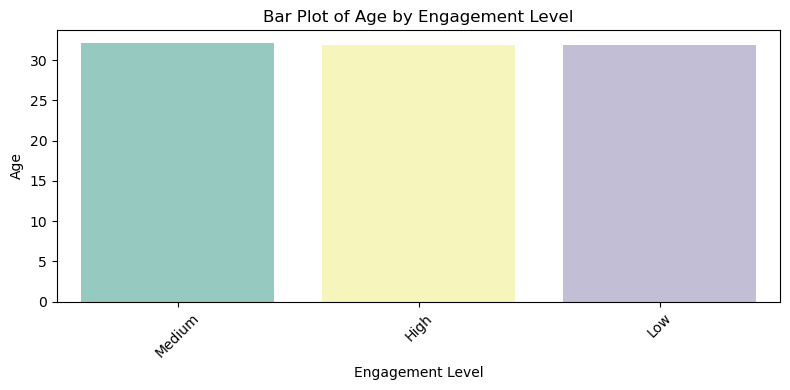


Summary Statistics for PlayTimeHours by Engagement Level:
                      mean     median  count
EngagementLevel                             
High             12.069238  11.981024  10336
Low              12.104915  12.074409  10324
Medium           11.957503  11.992280  19374


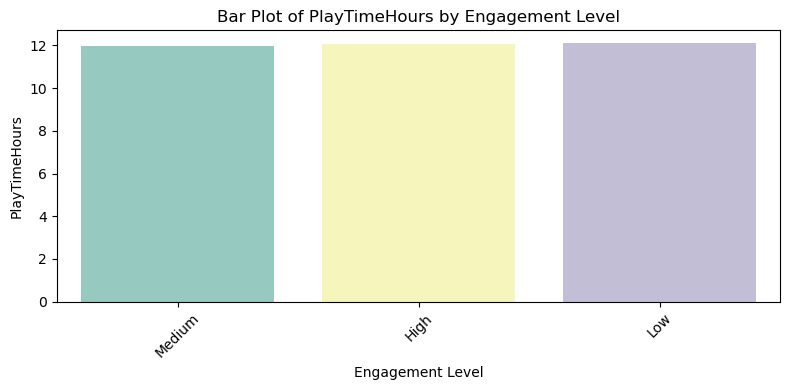


Summary Statistics for InGamePurchases by Engagement Level:
                     mean  median  count
EngagementLevel                         
High             0.206463     0.0  10336
Low              0.197307     0.0  10324
Medium           0.199752     0.0  19374


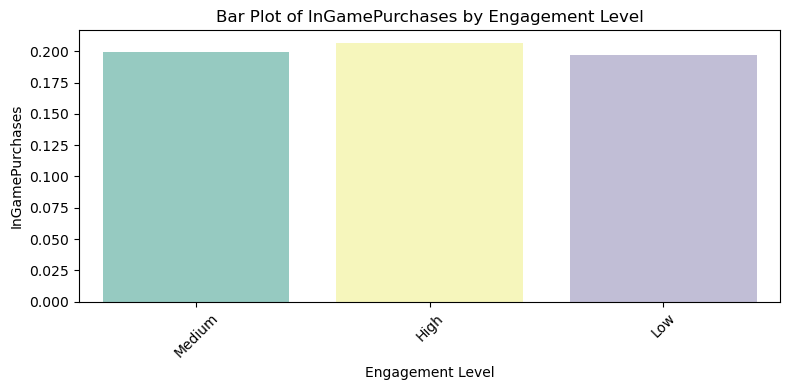


Summary Statistics for SessionsPerWeek by Engagement Level:
                      mean  median  count
EngagementLevel                          
High             14.254547    15.0  10336
Low               4.530511     3.0  10324
Medium            9.553267     9.0  19374


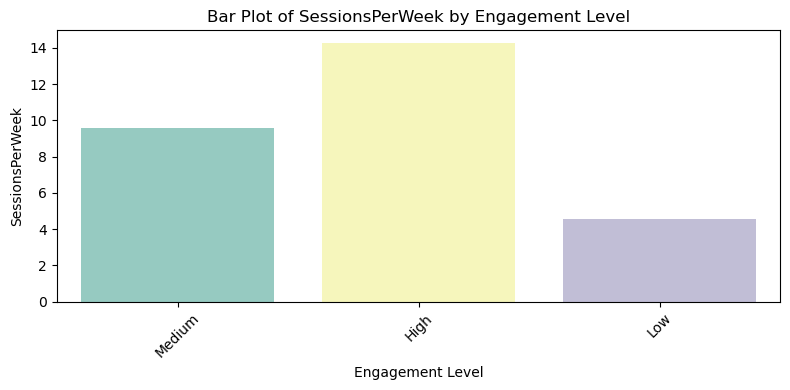


Summary Statistics for AvgSessionDurationMinutes by Engagement Level:
                       mean  median  count
EngagementLevel                           
High             131.921827   137.0  10336
Low               66.882119    53.0  10324
Medium            89.856405    84.0  19374


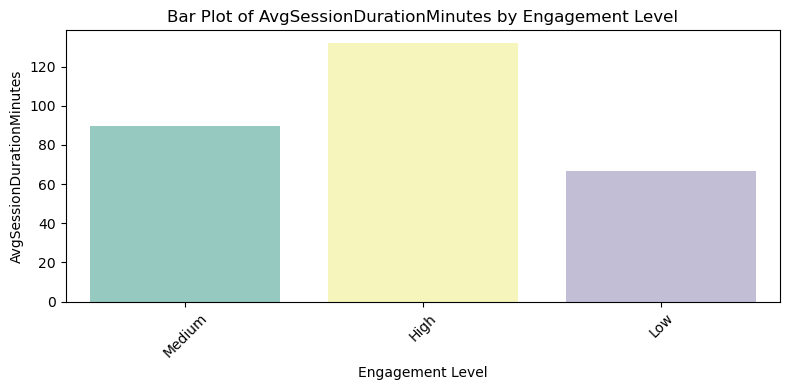


Summary Statistics for PlayerLevel by Engagement Level:
                      mean  median  count
EngagementLevel                          
High             50.823723    51.0  10336
Low              46.101414    44.0  10324
Medium           50.926293    51.0  19374


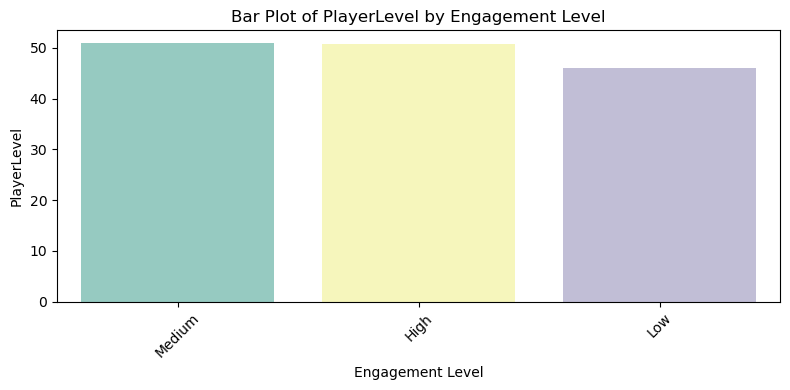


Summary Statistics for AchievementsUnlocked by Engagement Level:
                      mean  median  count
EngagementLevel                          
High             25.095975    25.0  10336
Low              22.661565    22.0  10324
Medium           25.216424    26.0  19374


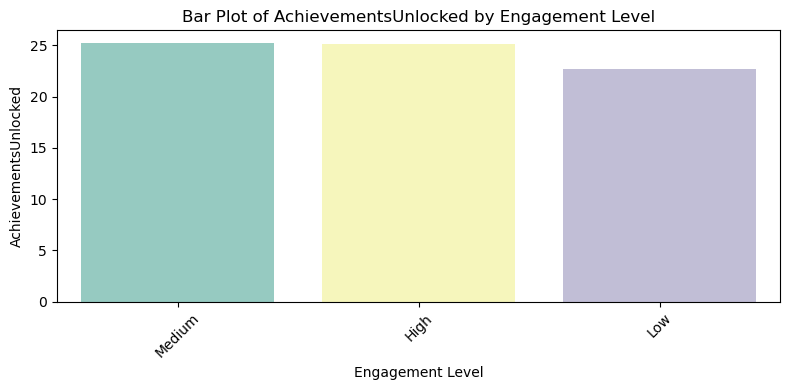

In [46]:
# Define the columns to analyze
columns_to_analyze = [
    'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 
    'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked'
]

# Loop through each feature to display summary statistics and bar plot
for column in columns_to_analyze:
    # Calculate summary statistics grouped by EngagementLevel
    stats = df.groupby('EngagementLevel')[column].agg(['mean', 'median', 'count'])
    
    # Display summary statistics
    print(f"\nSummary Statistics for {column} by Engagement Level:")
    print(stats)
    
    # Plot bar plot
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x='EngagementLevel', y=column, ci=None, palette='Set3')
    plt.title(f'Bar Plot of {column.replace("_", " ")} by Engagement Level')
    plt.xlabel('Engagement Level')
    plt.ylabel(column.replace('_', ' '))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### **Insights**

#### 1. **Age**
- The average age of players is quite consistent across engagement levels, with no significant variation. This suggests that age may not be a strong differentiator for engagement levels in this dataset.

**Recommendations**:
- Since age does not vary significantly by engagement level, consider focusing on other factors (like game genre preferences or play styles) to enhance engagement strategies.

#### 2. **PlayTimeHours**
- Players with high engagement have slightly lower average playtime hours compared to those with low engagement, which is counterintuitive since one might expect higher engagement to correlate with more playtime.

**Recommendations**:
- Investigate the nature of high engagement—players may be playing shorter but more intense sessions. Consider introducing features that encourage longer session durations for highly engaged players.

#### 3. **InGamePurchases**
- The percentage of players making in-game purchases is relatively similar across all engagement levels, indicating that purchase behavior does not significantly differ based on how engaged players are.

**Recommendations**:
- Explore strategies to increase in-game purchases among low and medium engagement players by offering incentives or promotions that encourage spending.

#### 4. **SessionsPerWeek**
- There is a clear trend showing that higher engagement correlates with more frequent gaming sessions per week. High-engagement players are almost three times more active than low-engagement players.

**Recommendations**:
- To increase player engagement, consider implementing features that encourage more frequent play sessions, such as daily challenges or rewards for logging in multiple days a week.

#### 5. **AvgSessionDurationMinutes**
- Players with high engagement have significantly longer average session durations compared to those with medium and low engagement levels.

**Recommendations**:
- Develop content that retains players for longer periods during each session—this could include immersive storylines or complex gameplay mechanics that encourage deeper involvement.

#### 6. **PlayerLevel**
- Player levels are relatively consistent across high and medium engagement levels but drop for low engagement players, indicating that more engaged players tend to progress further in the game.

**Recommendations**:
- Consider implementing a mentorship or guidance system where higher-level players can assist lower-level players to improve their experience and encourage progression.

#### 7. **AchievementsUnlocked**
- Players with medium and high engagement unlock a similar number of achievements on average compared to those with low engagement who unlock fewer achievements.

**Recommendations**:
- Enhance the achievement system to provide more engaging challenges for lower-engagement players to motivate them to unlock achievements and increase their overall game involvement.

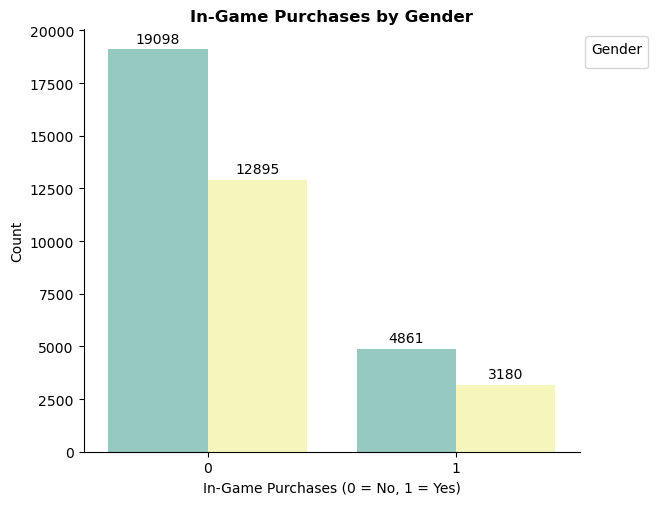

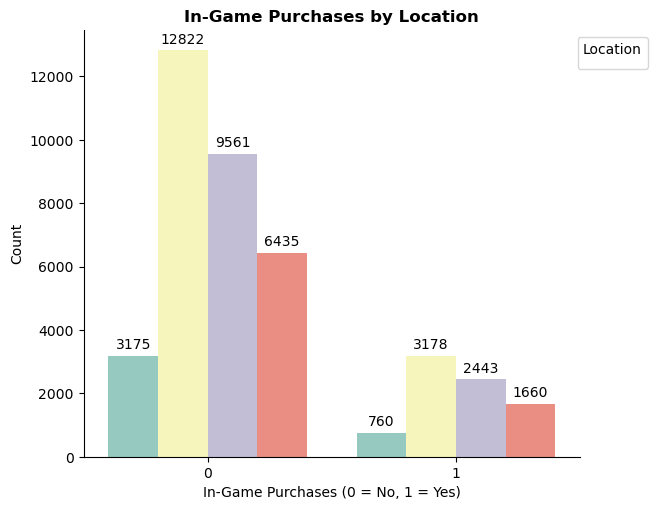

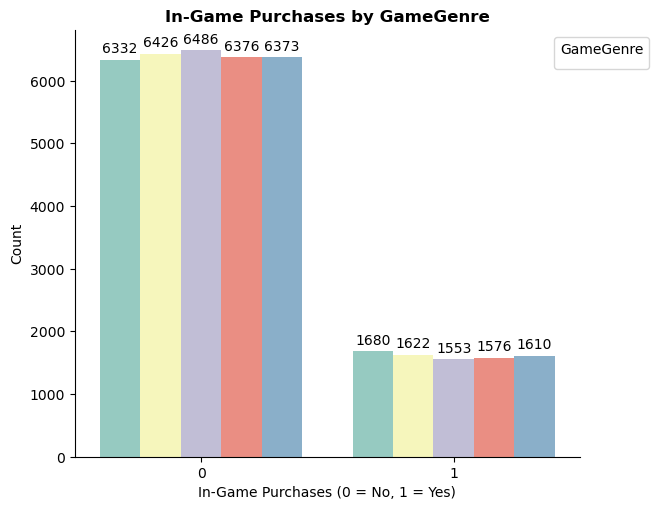

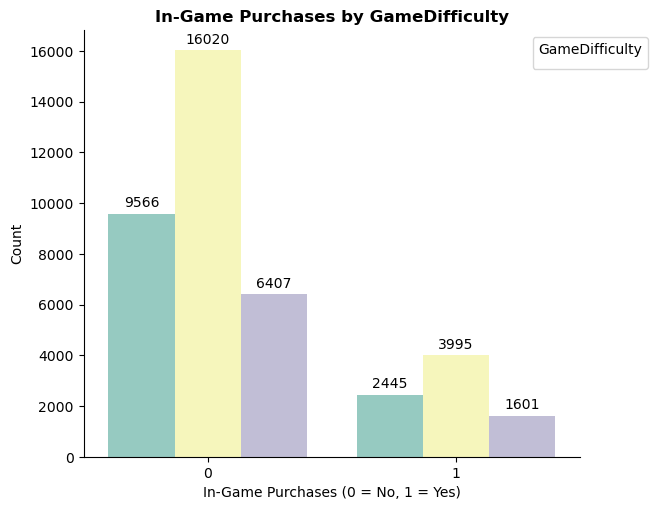

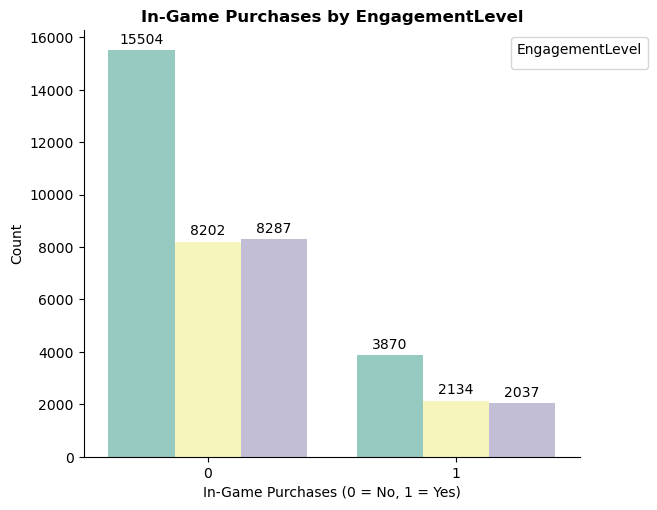

In [47]:
# Define the categorical columns to analyze against 'InGamePurchases'
categorical_columns = ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']

# Loop through each categorical column to create catplots
for column in categorical_columns:
    # Create the catplot for InGamePurchases vs the current categorical column
    g = sns.catplot(
        data=df,
        x='InGamePurchases', 
        hue=column, 
        kind='count',
        height=5, 
        aspect=1.2,
        palette='Set3',
        legend=False
    )

    g.set_axis_labels("In-Game Purchases (0 = No, 1 = Yes)", "Count")
    plt.title(f'In-Game Purchases by {column}', weight='bold')

    for ax in g.axes.flat:
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', 
                        va='baseline', 
                        fontsize=10, 
                        color='black', 
                        xytext=(0, 5), 
                        textcoords='offset points')

    plt.legend(
        title=column,
        loc='upper right',
        bbox_to_anchor=(1.15, 1)
    )

    plt.show()


### **Insights from In-Game Purchases vs Categorical Columns**

#### **1. Counts of In-Game Purchases by Gender**
| **Gender** | **No Purchase (0)** | **Purchase (1)** | **Purchase Rate (%)** |
|------------|----------------------|-------------------|------------------------|
| Female     | 12,895              | 3,180             | 19.8%                 |
| Male       | 19,098              | 4,861             | 20.3%                 |

- **Observations**:
  - Males are slightly more likely to make in-game purchases (approximately 20.3%) compared to females (approximately 19.8%).
  - The majority of players, irrespective of gender, do not engage in in-game purchases.

- **Recommendations**:
  - Develop gender-targeted marketing strategies to encourage more purchases, such as exclusive offers or promotions tailored for female gamers.

#### **2. Counts of In-Game Purchases by Location**
| **Location** | **No Purchase (0)** | **Purchase (1)** | **Purchase Rate (%)** |
|--------------|----------------------|-------------------|------------------------|
| Asia         | 6,435               | 1,660             | 20.5%                 |
| Europe       | 9,561               | 2,443             | 20.4%                 |
| Other        | 3,175               | 760               | 19.3%                 |
| USA          | 12,822              | 3,178             | 19.9%                 |

- **Observations**:
  - The USA has the highest number of players overall but a lower purchase rate (19.9%) compared to Asia (20.5%).
  - Asia exhibits a slightly higher purchase rate despite having fewer players overall.

- **Recommendations**:
  - Localize marketing strategies to boost purchases in regions with lower rates, such as the USA and "Other."
  - Consider regional cultural preferences when designing in-game items or promotions.


#### **3. Counts of In-Game Purchases by Game Genre**
| **Game Genre** | **No Purchase (0)** | **Purchase (1)** | **Purchase Rate (%)** |
|----------------|----------------------|-------------------|------------------------|
| Action         | 6,486               | 1,553             | 19.3%                 |
| RPG            | 6,376               | 1,576             | 19.8%                 |
| Simulation     | 6,373               | 1,610             | 20.2%                 |
| Sports         | 6,426               | 1,622             | 20.2%                 |
| Strategy       | 6,332               | 1,680             | 21.0%                 |

- **Observations**:
  - Strategy games have the highest purchase rate (21.0%), while Action games have the lowest (19.3%).
  - Other genres show consistent purchase rates around 20%.

- **Recommendations**:
  - Enhance in-game content for Action games to boost purchases, such as unique in-game items or limited-time events.
  - Promote Strategy games further, as players in this genre are already more likely to spend.


#### **4. Counts of In-Game Purchases by Game Difficulty**
| **Game Difficulty** | **No Purchase (0)** | **Purchase (1)** | **Purchase Rate (%)** |
|----------------------|----------------------|-------------------|------------------------|
| Easy                | 16,020              | 3,995             | 19.9%                 |
| Hard                | 6,407               | 1,601             | 20.0%                 |
| Medium              | 9,566               | 2,445             | 20.4%                 |

- **Observations**:
  - Players on Medium difficulty are slightly more likely to make purchases (20.4%) compared to Easy (19.9%) or Hard (20.0%).
  - Easier modes may discourage spending due to reduced gameplay challenges.

- **Recommendations**:
  - Introduce exclusive items or bonuses that appeal to players on Easy mode to encourage purchases.
  - Maintain the balance in Medium and Hard difficulties while integrating more purchasable content.

#### **5. Counts of In-Game Purchases by Engagement Level**
| **Engagement Level** | **No Purchase (0)** | **Purchase (1)** | **Purchase Rate (%)** |
|-----------------------|----------------------|-------------------|------------------------|
| High                 | 8,202               | 2,134             | 20.6%                 |
| Low                  | 8,287               | 2,037             | 19.7%                 |
| Medium               | 15,504              | 3,870             | 20.0%                 |

- **Observations**:
  - High engagement players have the highest purchase rate (20.6%), followed by Medium (20.0%).
  - Low engagement players are the least likely to make purchases (19.7%).

- **Recommendations**:
  - Focus on converting Medium engagement players into High engagement players by offering rewards or exclusive benefits for frequent play.
  - Use personalized in-game messaging for Low engagement players to encourage spending.

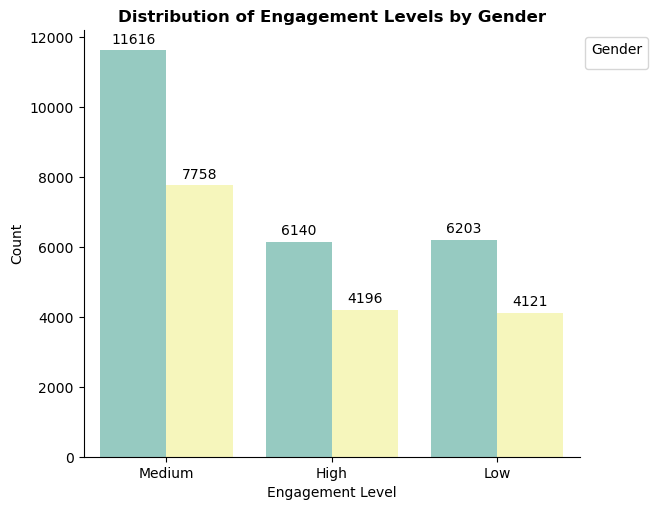

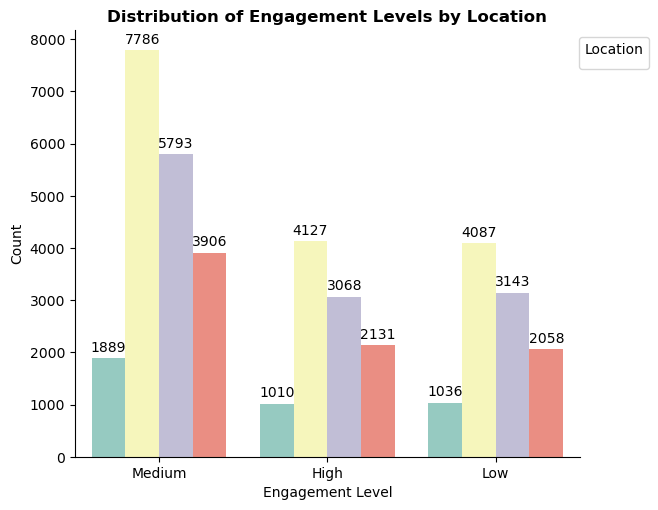

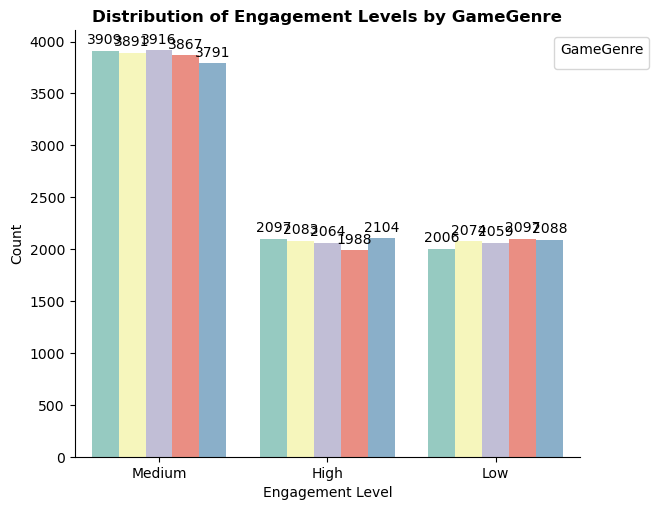

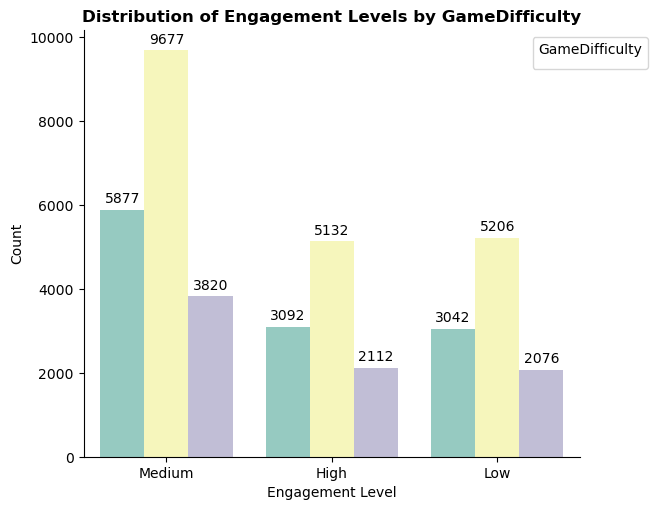

In [48]:
# Define the categorical columns to analyze against 'EngagementLevel'
categorical_columns = ['Gender', 'Location', 'GameGenre', 'GameDifficulty']

for column in categorical_columns:
    # Create the catplot for EngagementLevel vs the current categorical column
    g = sns.catplot(
        data=df,
        x='EngagementLevel', 
        hue=column, 
        kind='count',
        height=5, 
        aspect=1.2,
        palette='Set3',
        legend=False
    )

    g.set_axis_labels("Engagement Level", "Count")
    plt.title(f'Distribution of Engagement Levels by {column}', weight='bold')

    for ax in g.axes.flat:
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', 
                        va='baseline', 
                        fontsize=10, 
                        color='black', 
                        xytext=(0, 5), 
                        textcoords='offset points')

    plt.legend(
        title=column,
        loc='upper right',
        bbox_to_anchor=(1.15, 1)
    )

    plt.show()


### **Insights from Engagement Level vs Categorical Columns**

#### **1. Counts and Percentages of Engagement Level by Gender**

| **Engagement Level** | **High**   | **Low**    | **Medium**  | **High (%)** | **Low (%)** | **Medium (%)** |
|-----------------------|------------|------------|-------------|--------------|-------------|----------------|
| Female               | 4,196      | 4,121      | 7,758       | 26.10        | 25.64       | 48.26          |
| Male                 | 6,140      | 6,203      | 11,616      | 25.63        | 25.89       | 48.48          |

- **Observations:**
	- **Medium engagement** is the most common for both genders, with males having a slightly higher percentage (48.5%) than females (48.3%).
	- Females have a slightly lower proportion of `High` and `Low` engagement compared to males.

- **Recommendations:**
	- Develop targeted content or features to increase high engagement among female players.
	- Include inclusive gaming environments or female-focused promotions to encourage higher participation.

#### **2. Counts and Percentages of Engagement Level by Location**

| **Engagement Level** | **High**   | **Low**    | **Medium**  | **High (%)** | **Low (%)** | **Medium (%)** |
|-----------------------|------------|------------|-------------|--------------|-------------|----------------|
| Asia                 | 2,131      | 2,058      | 3,906       | 26.32        | 25.42       | 48.25          |
| Europe               | 3,068      | 3,143      | 5,793       | 25.56        | 26.18       | 48.26          |
| Other                | 1,010      | 1,036      | 1,889       | 25.67        | 26.33       | 48.01          |
| USA                  | 4,127      | 4,087      | 7,786       | 25.79        | 25.54       | 48.66          |

- **Observations:**
	- Asia shows the highest percentage of high engagement (26.3%).
	- The USA leads in total player counts across all engagement levels, with a strong proportion of medium engagement (48.7%).

- **Recommendations:**
	- Increase player retention in Europe and "Other" regions by offering localized promotions or features aimed at boosting high engagement levels.
	- Capitalize on the high engagement in Asia by providing exclusive rewards or events for players.

#### **3. Counts and Percentages of Engagement Level by Game Genre**

| **Engagement Level** | **High**   | **Low**    | **Medium**  | **High (%)** | **Low (%)** | **Medium (%)** |
|-----------------------|------------|------------|-------------|--------------|-------------|----------------|
| Action               | 2,064      | 2,059      | 3,916       | 25.67        | 25.61       | 48.71          |
| RPG                  | 1,988      | 2,097      | 3,867       | 25.00        | 26.37       | 48.63          |
| Simulation           | 2,104      | 2,088      | 3,791       | 26.36        | 26.16       | 47.49          |
| Sports               | 2,083      | 2,074      | 3,891       | 25.88        | 25.77       | 48.35          |
| Strategy             | 2,097      | 2,006      | 3,909       | 26.17        | 25.04       | 48.79          |

- **Observations:**
	- Strategy games have the highest proportion of high engagement (26.2%).
	- RPGs have the highest low engagement percentage (26.4%), suggesting room for improvement in retaining players at higher engagement levels.

- **Recommendations:**
	- Focus on improving features for RPG players to reduce low engagement.
	- Use the success of Strategy games as a model to increase engagement across other genres.

#### **4. Counts and Percentages of Engagement Level by Game Difficulty**

| **Engagement Level** | **High**   | **Low**    | **Medium**  | **High (%)** | **Low (%)** | **Medium (%)** |
|-----------------------|------------|------------|-------------|--------------|-------------|----------------|
| Easy                 | 5,132      | 5,206      | 9,677       | 25.64        | 26.01       | 48.35          |
| Hard                 | 2,112      | 2,076      | 3,820       | 26.37        | 25.92       | 47.70          |
| Medium               | 3,092      | 3,042      | 5,877       | 25.74        | 25.33       | 48.93          |

- **Observations:**
	- Medium difficulty has the highest medium engagement percentage (48.9%).
	- Hard difficulty players show the highest proportion of high engagement (26.4%), indicating that challenges motivate retention.

- **Recommendations:**
	- Promote harder difficulties with exclusive rewards or achievements to encourage players to engage at higher levels.
	- For Easy difficulty, provide progressive incentives to encourage players to increase their engagement.

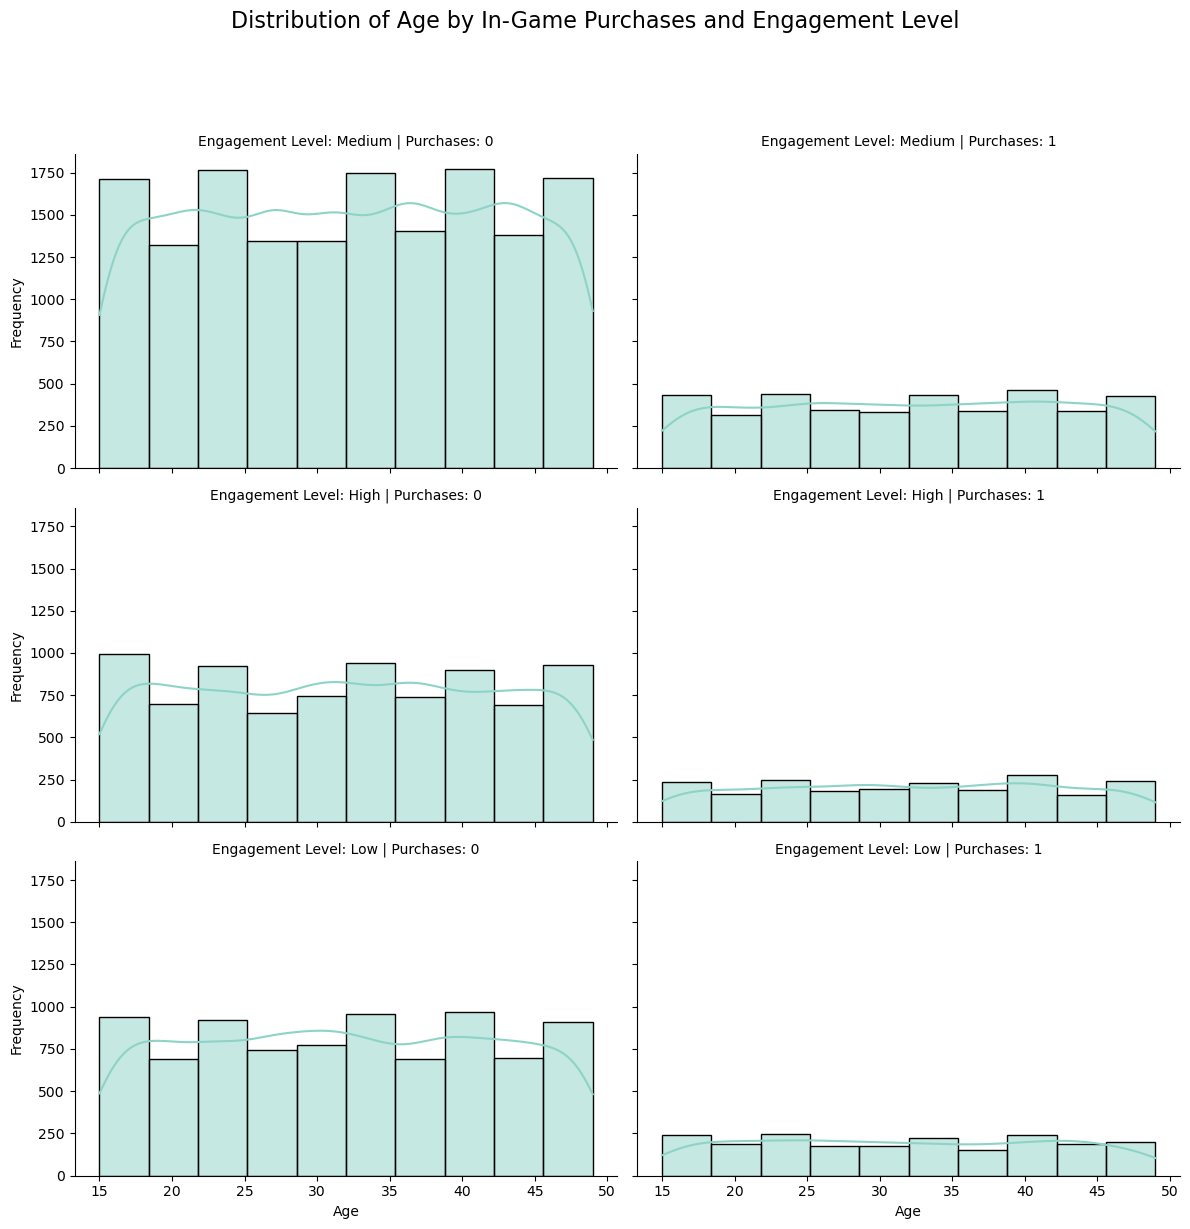

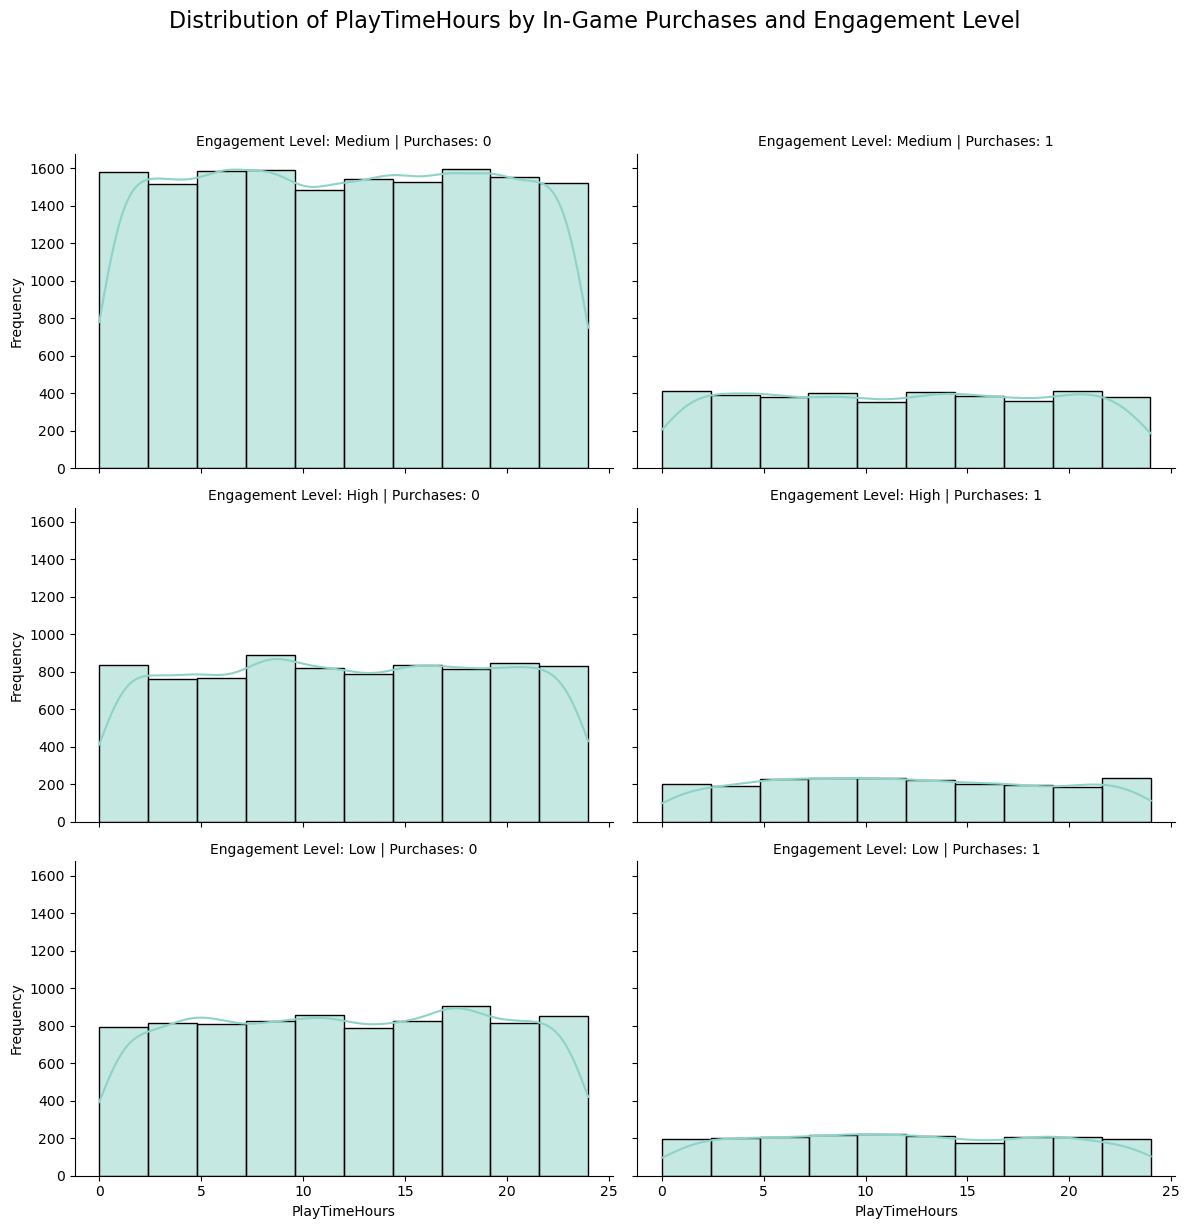

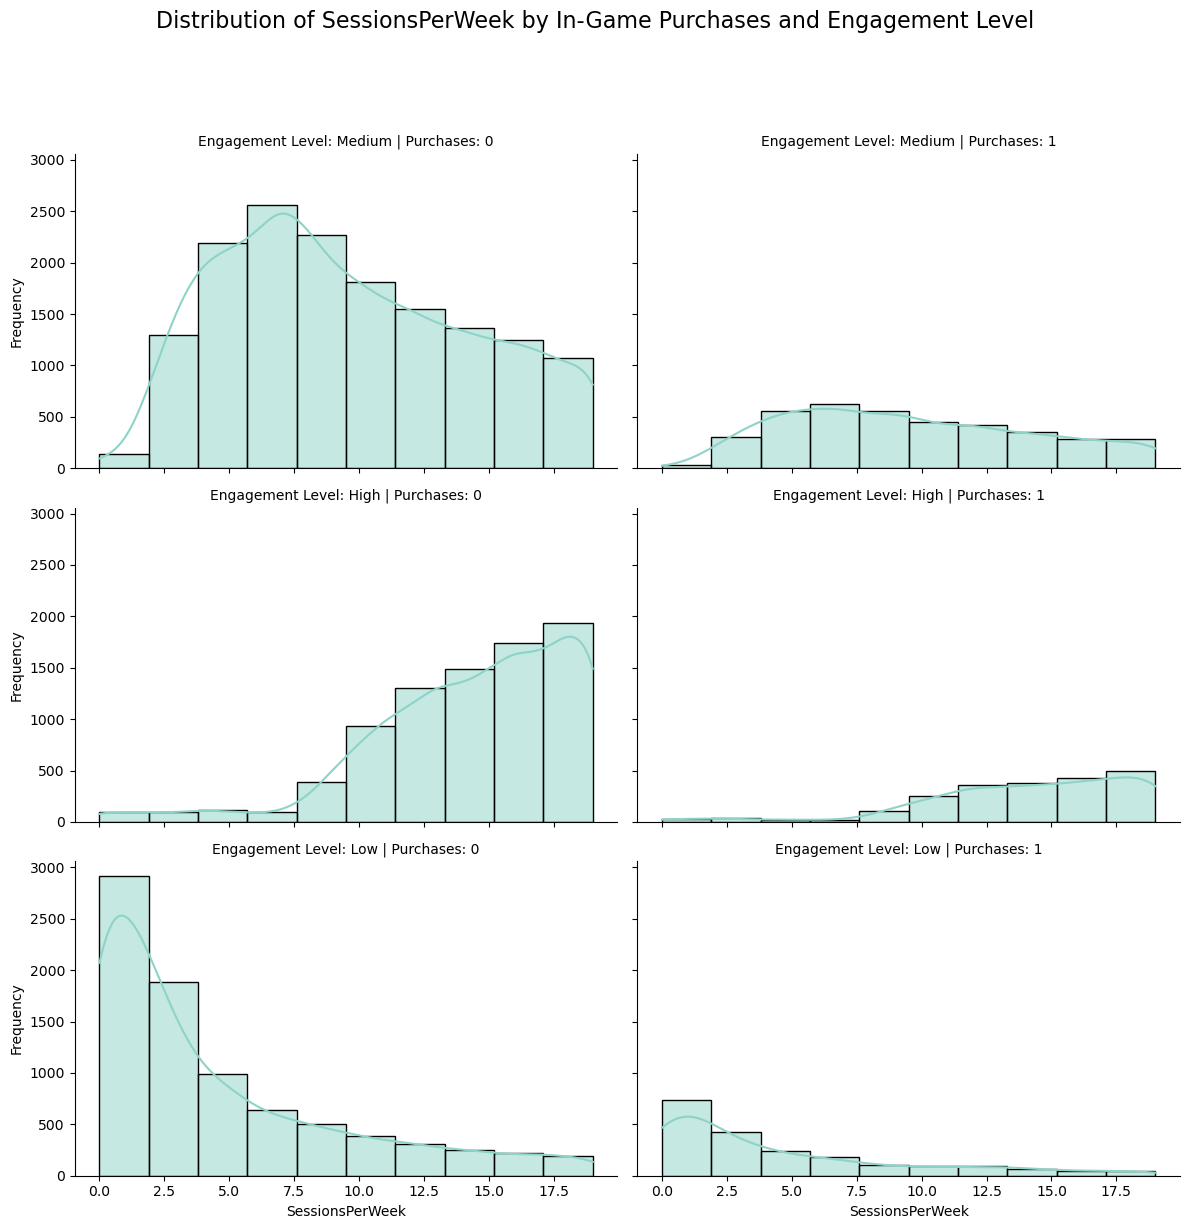

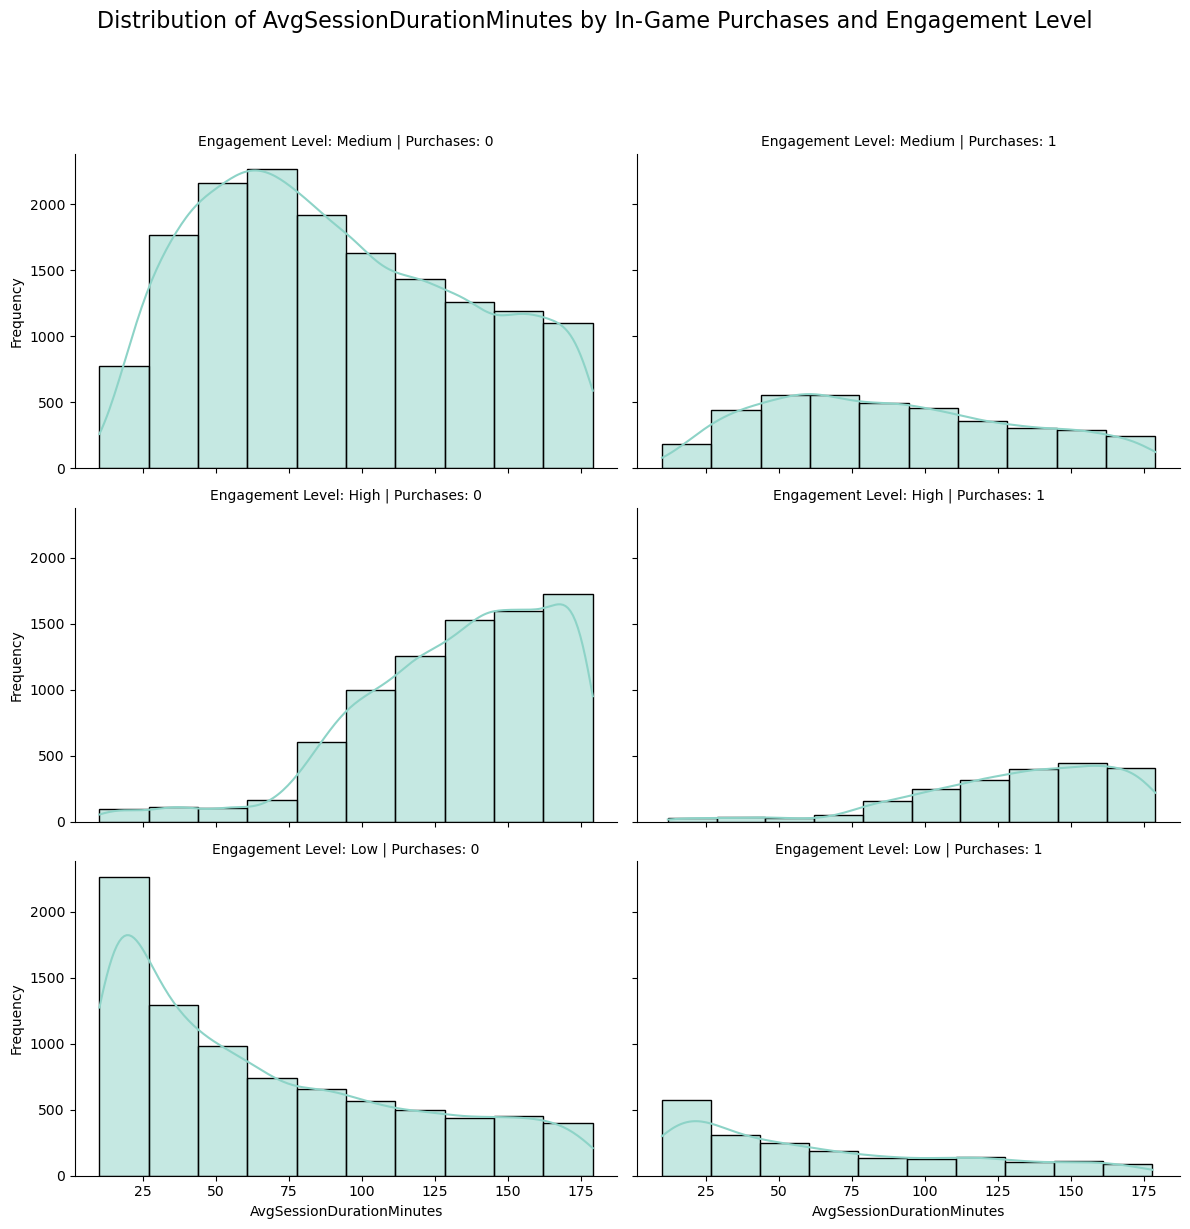

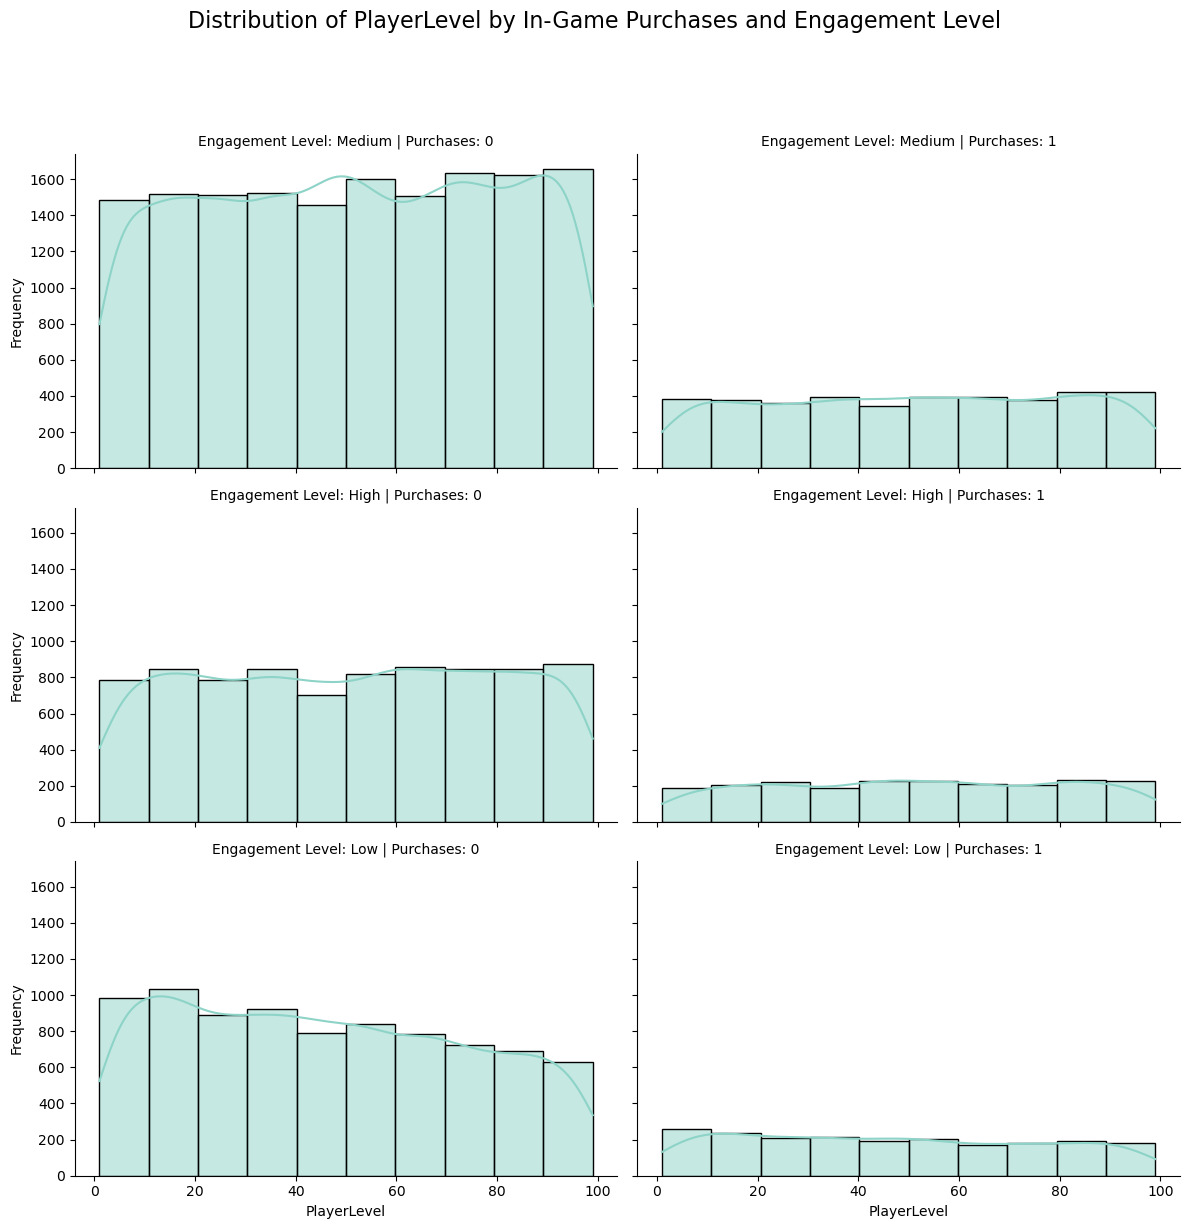

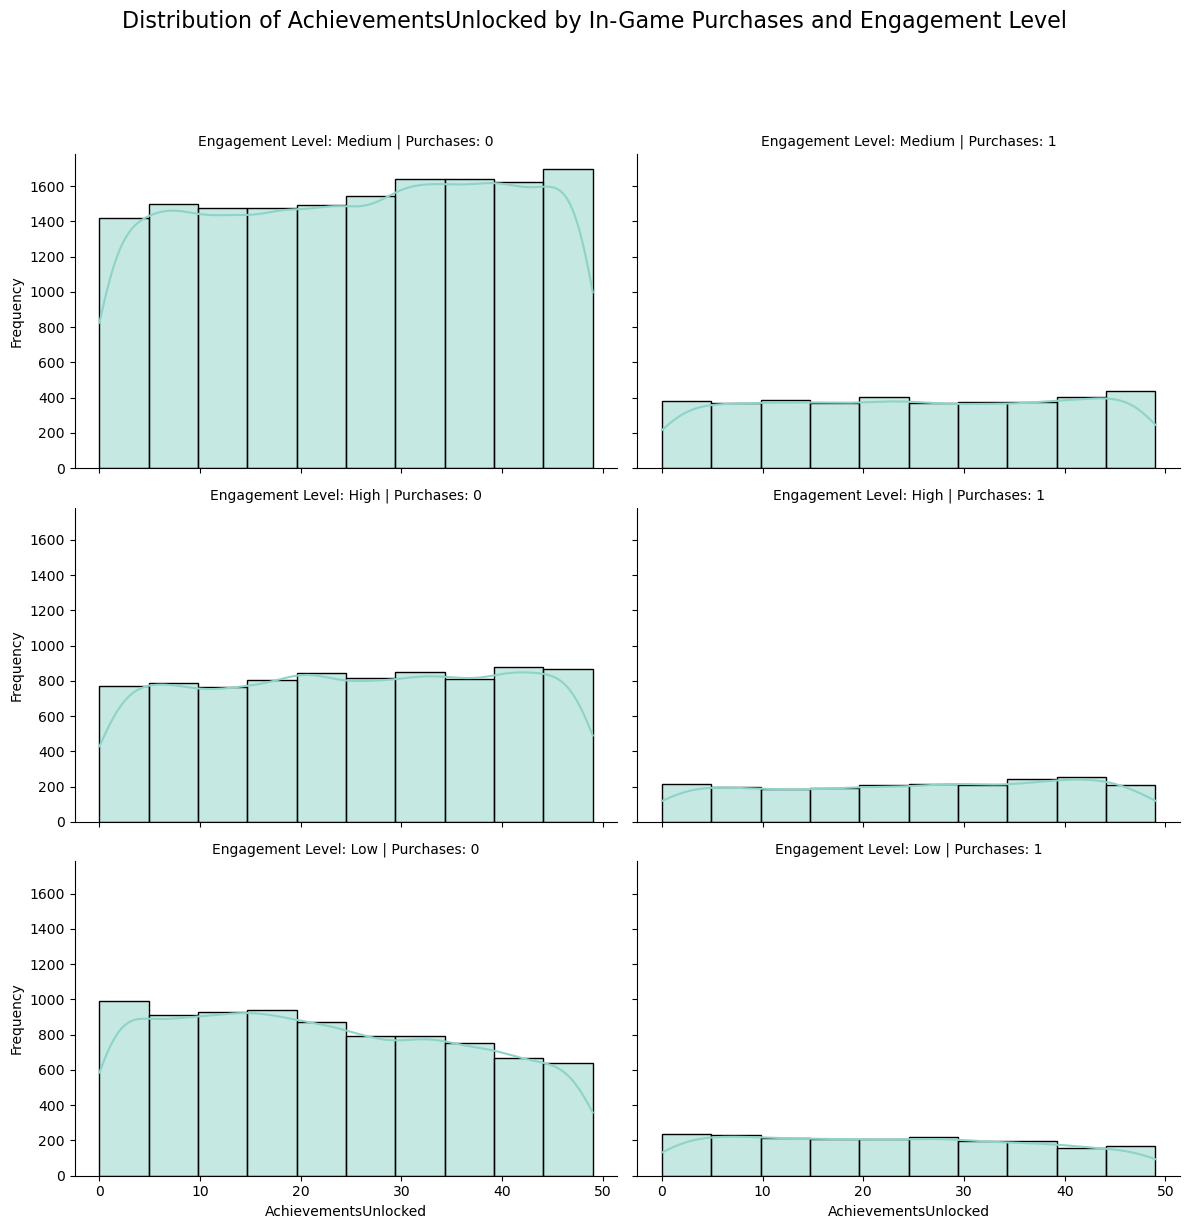

In [49]:
# Define the numerical features to plot against InGamePurchases by EngagementLevel
numerical_features = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 
                      'AvgSessionDurationMinutes', 'PlayerLevel', 
                      'AchievementsUnlocked']

# Loop through each numerical feature to create FacetGrid plots by EngagementLevel and InGamePurchases
for feature in numerical_features:
    g = sns.FacetGrid(
        df, 
        row='EngagementLevel', 
        col='InGamePurchases', 
        height=4, 
        aspect=1.5, 
        sharex=True, 
        sharey=True
    )
    
    # Map the histogram with KDE for each feature
    g.map(sns.histplot, feature, kde=True, bins=10, color=sns.color_palette("Set3")[0])
    
    # Set axis labels and titles
    g.set_axis_labels(feature.replace('_', ' '), 'Frequency')
    g.set_titles("Engagement Level: {row_name} | Purchases: {col_name}")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(
        f'Distribution of {feature.replace("_", " ")} by In-Game Purchases and Engagement Level', 
        fontsize=16, 
        y=1.02
    )
    
    plt.show()


### **Insights**

#### **1. Age**
- Across all engagement levels and purchase behaviors, the age distribution remains consistent.
- Players are predominantly within the 20–40 age range.
- Age is not a significant factor influencing engagement or purchase behavior.

#### **2. PlayTimeHours**
- Purchasers (`InGamePurchases = 1`) show higher average playtime across all engagement levels compared to non-purchasers.
- Players with high engagement levels exhibit the longest playtime, regardless of purchase behavior.
- Playtime is positively correlated with both engagement and purchasing behavior.

#### **3. SessionsPerWeek**
- Players with higher engagement and purchase behavior tend to log more sessions per week.
- Non-purchasers have a more even spread across lower session counts, while purchasers are clustered around 10–15 sessions.
- Frequent sessions are a strong indicator of purchasing behavior, particularly for highly engaged players.

#### **4. AvgSessionDurationMinutes**
- Players making purchases tend to have slightly longer session durations compared to non-purchasers, especially at high engagement levels.
- Non-purchasers are more evenly distributed across shorter session durations.
- Longer session durations reflect higher engagement, leading to increased spending behavior.

#### **5. PlayerLevel**
- Purchasers generally achieve higher player levels across all engagement categories.
- Non-purchasers remain distributed across lower levels, with fewer players progressing to advanced levels.
- Higher levels indicate deeper gameplay involvement, making advanced players more likely to spend.

#### **6. AchievementsUnlocked**
- Players with high engagement and purchasing behavior unlock significantly more achievements.
- Non-purchasers generally unlock fewer achievements, with a wider spread across engagement levels.
- Achievement count is a clear indicator of engagement and potential spending.


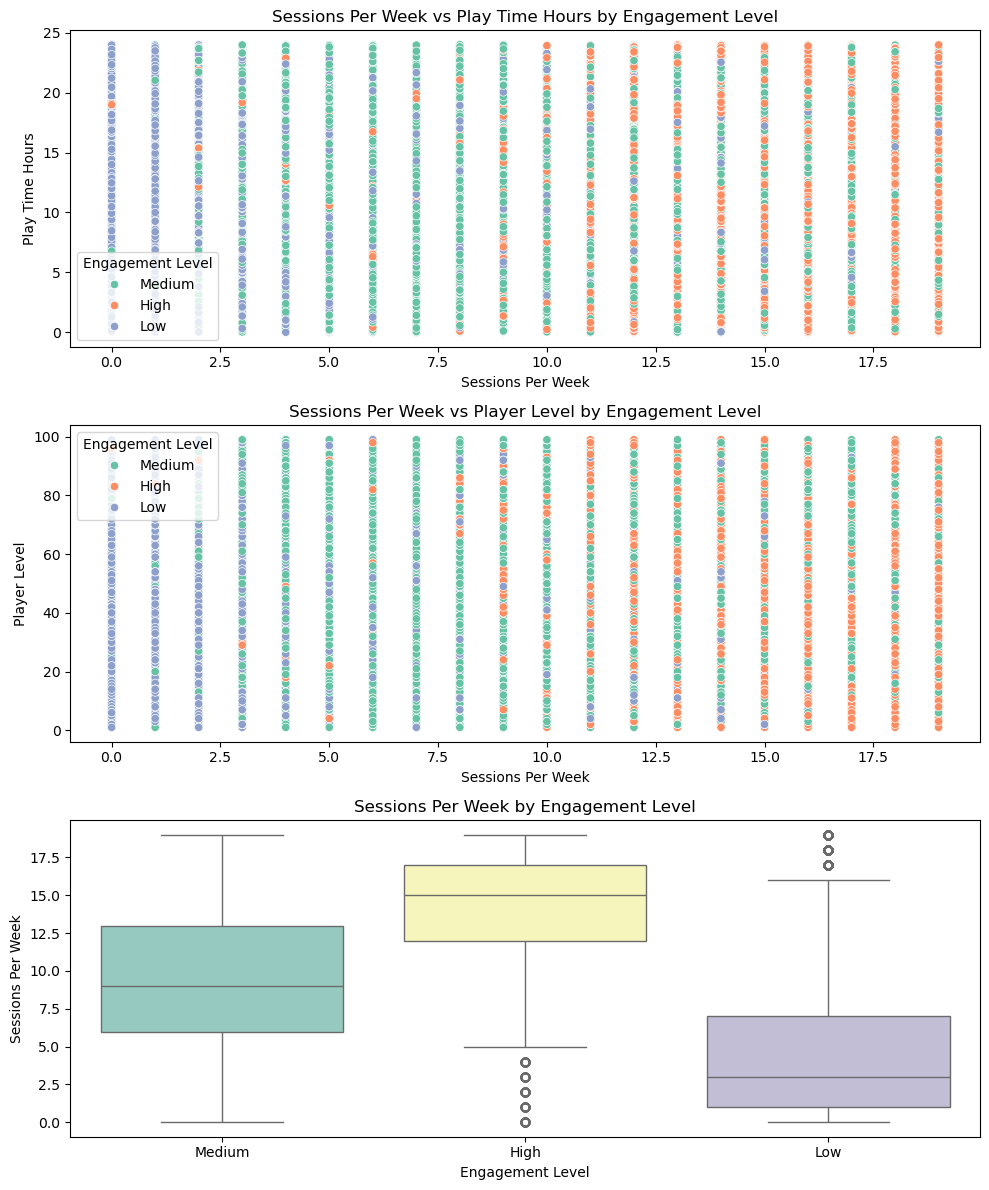

In [50]:
# PlayTimeHours and PlayerLevel vs SessionsPerWeek
plt.figure(figsize=(10, 12))

# First scatter plot: SessionsPerWeek vs PlayTimeHours
plt.subplot(3, 1, 1)
sns.scatterplot(data=df, x='SessionsPerWeek', y='PlayTimeHours', hue='EngagementLevel', palette='Set2')
plt.title("Sessions Per Week vs Play Time Hours by Engagement Level")
plt.xlabel("Sessions Per Week")
plt.ylabel("Play Time Hours")
plt.legend(title='Engagement Level')

# Second scatter plot: SessionsPerWeek vs PlayerLevel
plt.subplot(3, 1, 2)
sns.scatterplot(data=df, x='SessionsPerWeek', y='PlayerLevel', hue='EngagementLevel', palette='Set2')
plt.title("Sessions Per Week vs Player Level by Engagement Level")
plt.xlabel("Sessions Per Week")
plt.ylabel("Player Level")
plt.legend(title='Engagement Level')

# Box plot for SessionsPerWeek by EngagementLevel
plt.subplot(3, 1, 3)
sns.boxplot(data=df, x='EngagementLevel', y='SessionsPerWeek', palette='Set3')
plt.title("Sessions Per Week by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Sessions Per Week")

# Show scatter plots
plt.tight_layout()
plt.show()

1. **Sessions Per Week vs Play Time Hours by Engagement Level**:
   - **High Engagement**:
     - Players tend to have higher values for both `SessionsPerWeek` and `PlayTimeHours`, clustering around 10–15 sessions and 15–20 hours.
   - **Medium Engagement**:
     - Players are moderately spread, mostly between 5–10 sessions and 5–15 hours of playtime.
   - **Low Engagement**:
     - Players are more scattered across lower session counts and playtime, often below 5 sessions and 10 hours.
   - **Insight**:
     - Higher playtime and session frequency strongly correlate with higher engagement levels.

2. **Sessions Per Week vs Player Level by Engagement Level**:
   - **High Engagement**:
     - Players reach higher levels (60–100) while maintaining frequent sessions (10–15 per week).
   - **Medium Engagement**:
     - Players exhibit moderate levels (30–60) with less frequent sessions (5–10 per week).
   - **Low Engagement**:
     - Players are concentrated at lower levels (below 30) and minimal session frequency.
   - **Insight**:
     - Consistent session frequency and higher progression in levels are key indicators of higher engagement.
    
3. **Sessions Per Week by Engagement Level**:
   - **High Engagement**:
     - Median sessions are highest, around 12–13 per week, with some outliers indicating players with more than 15 sessions.
   - **Medium Engagement**:
     - Median is around 7–8 sessions, with a smaller range than high engagement.
   - **Low Engagement**:
     - Median is low, around 2–3 sessions, and variability is minimal.
   - **Insight**:
     - Increasing session frequency could help transition low- and medium-engaged players to higher engagement levels.

#### Key Recommendations:
1. **Boost Engagement for Low and Medium Groups**:
   - Introduce events or challenges targeting session frequency and longer playtime for these players.
   
2. **Reward Progression**:
   - Offer incentives tied to reaching higher levels to motivate players to stay engaged.

3. **Segmented Retention Strategies**:
   - Use insights from these visualizations to design tailored interventions for each engagement group. 

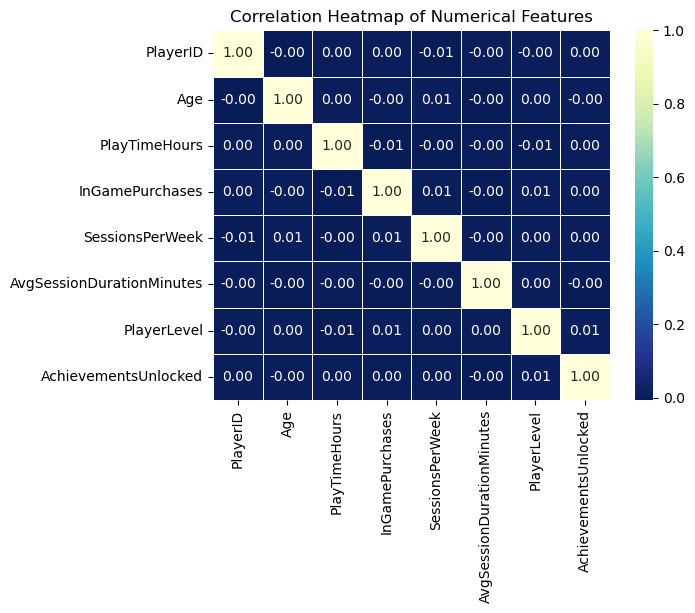

In [51]:
# Correlation heatmap
numerical_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_columns.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu_r", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### **Overall Observations**
1. **Mostly Weak Inter-Feature Correlations**:
   - Most features show near-zero correlations with each other, suggesting that metrics like `PlayTimeHours`, `InGamePurchases`, and `SessionsPerWeek` capture distinct aspects of player behavior.
   - This independence is beneficial for modeling — it means each feature contributes unique information and reduces multicollinearity concerns.

2. **Noteworthy Relationships**:
   - `SessionsPerWeek` and `AvgSessionDurationMinutes` show the strongest associations with engagement, confirming that session-related metrics are the primary engagement drivers.
   - `PlayerLevel` and `AchievementsUnlocked` have weak but meaningful links to engagement and purchases.

3. **Practical Implications**:
   - Since no single feature dominates, a multi-feature modeling approach (like tree-based ensembles) is well-suited for this dataset.
   - Retention strategies should target players with low session frequency or few achievements, as these are early warning signs of disengagement.

## Data Preprocessing

### Function to Encode Categorical Features

1. **Gender**:
   - Binary Encoding: `Male = 1`, `Female = 0`.

2. **Location**:
   - One-Hot Encoding: Adds columns like `Location_Europe`, `Location_Other`, `Location_USA`.

3. **GameGenre**:
   - One-Hot Encoding: Adds columns like `Genre_Action`, `Genre_RPG`, `Genre_Simulation`.

4. **GameDifficulty**:
   - Ordinal Encoding: Maps `Easy = 1`, `Medium = 2`, `Hard = 3`.

5. **EngagementLevel**:
   - Ordinal Encoding: Maps `Low = 1`, `Medium = 2`, `High = 3`.

In [52]:
def encode_categorical_features(df):
    # Encode Gender using Label Encoding
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    
    # Encode Location using One-Hot Encoding
    df = pd.get_dummies(df, columns=['Location'], drop_first=True, prefix='Location')
    
    # Encode GameGenre using One-Hot Encoding
    df = pd.get_dummies(df, columns=['GameGenre'], drop_first=True, prefix='Genre')
    
    # Encode GameDifficulty using Ordinal Encoding 
    difficulty_mapping = {'Easy': 1, 'Medium': 2, 'Hard': 3}
    df['GameDifficulty'] = df['GameDifficulty'].map(difficulty_mapping)
    
    # Encode EngagementLevel using Ordinal Encoding 
    engagement_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df['EngagementLevel'] = df['EngagementLevel'].map(engagement_mapping)
    
    return df

# Apply the function to the DataFrame
encoded_data = encode_categorical_features(df)

# Display the first few rows of the encoded DataFrame
encoded_data.head()


,PlayerID,Age,Gender,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Europe,Location_Other,Location_USA,Genre_RPG,Genre_Simulation,Genre_Sports,Genre_Strategy
0,9000,43,0,16.271119,0,2,6,108,79,25,1,False,True,False,False,False,False,True
1,9001,29,1,5.525961,0,2,5,144,11,10,1,False,False,True,False,False,False,True
2,9002,22,1,8.223755,0,1,16,142,35,41,2,False,False,True,False,False,True,False
3,9003,35,0,5.265351,1,1,9,85,57,47,1,False,False,True,False,False,False,False
4,9004,33,0,15.531945,0,2,2,131,95,37,1,True,False,False,False,False,False,False


In [53]:
# Check the unique values for encoded features
encoded_features = ['Gender', 'GameDifficulty', 'EngagementLevel', 
                    'Location_Europe', 'Location_Other', 'Location_USA', 
                    'Genre_RPG', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy']

unique_values = {feature: encoded_data[feature].unique() for feature in encoded_features}

# Display the unique values for each encoded feature
unique_values

{'Gender': array([0, 1]),
 'GameDifficulty': array([2, 1, 3]),
 'EngagementLevel': array([1, 2, 0]),
 'Location_Europe': array([False,  True]),
 'Location_Other': array([ True, False]),
 'Location_USA': array([False,  True]),
 'Genre_RPG': array([False,  True]),
 'Genre_Simulation': array([False,  True]),
 'Genre_Sports': array([False,  True]),
 'Genre_Strategy': array([ True, False])}

In [54]:
# Calculate correlations with EngagementLevel
correlations_with_EngagementLevel = encoded_data.corr()['EngagementLevel'].sort_values(ascending=False)

# Convert to DataFrame
correlation_table = correlations_with_EngagementLevel.to_frame(name='Correlation with EngagementLevel').reset_index()

# Rename columns for clarity
correlation_table.rename(columns={'index': 'Feature'}, inplace=True)

# Display the correlation table
display(correlation_table)

,Feature,Correlation with EngagementLevel
0,EngagementLevel,1.000000
1,SessionsPerWeek,0.605996
2,AvgSessionDurationMinutes,0.476698
3,AchievementsUnlocked,0.060576
4,PlayerLevel,0.059315
5,InGamePurchases,0.008209
6,Genre_Strategy,0.007700
7,GameDifficulty,0.005057
8,Gender,0.004978
9,Location_USA,0.002499


### Insights from the Correlation with `EngagementLevel`:

1. **Strong Positive Correlation:**
   - **`SessionsPerWeek` (0.606)**:
     - This feature has the highest correlation with `EngagementLevel`, indicating that players who engage in more sessions per week are likely to have higher engagement levels.
     - **Implication**: Encouraging frequent sessions is a critical factor for boosting engagement.

2. **Moderate Positive Correlation:**
   - **`AvgSessionDurationMinutes` (0.477)**:
     - Average session duration is moderately correlated with engagement. Players who spend more time per session are more likely to have higher engagement levels.
     - **Implication**: Longer, meaningful play sessions contribute positively to engagement.

3. **Weak Positive Correlations:**
   - **`AchievementsUnlocked` (0.061)**:
     - A weak but positive correlation suggests that unlocking achievements slightly contributes to higher engagement.
     - **Implication**: While achievements may not strongly drive engagement, they can complement other strategies to retain players.
   - **`PlayerLevel` (0.059)**:
     - Player level also shows a weak correlation with engagement, indicating that progressing to higher levels may contribute to engagement but is not a dominant factor.
     - **Implication**: Players progressing to higher levels might already be inherently engaged.

4. **Neutral Correlation:**
   - Features not listed here have near-zero correlations with `EngagementLevel`, suggesting they don't directly influence engagement.


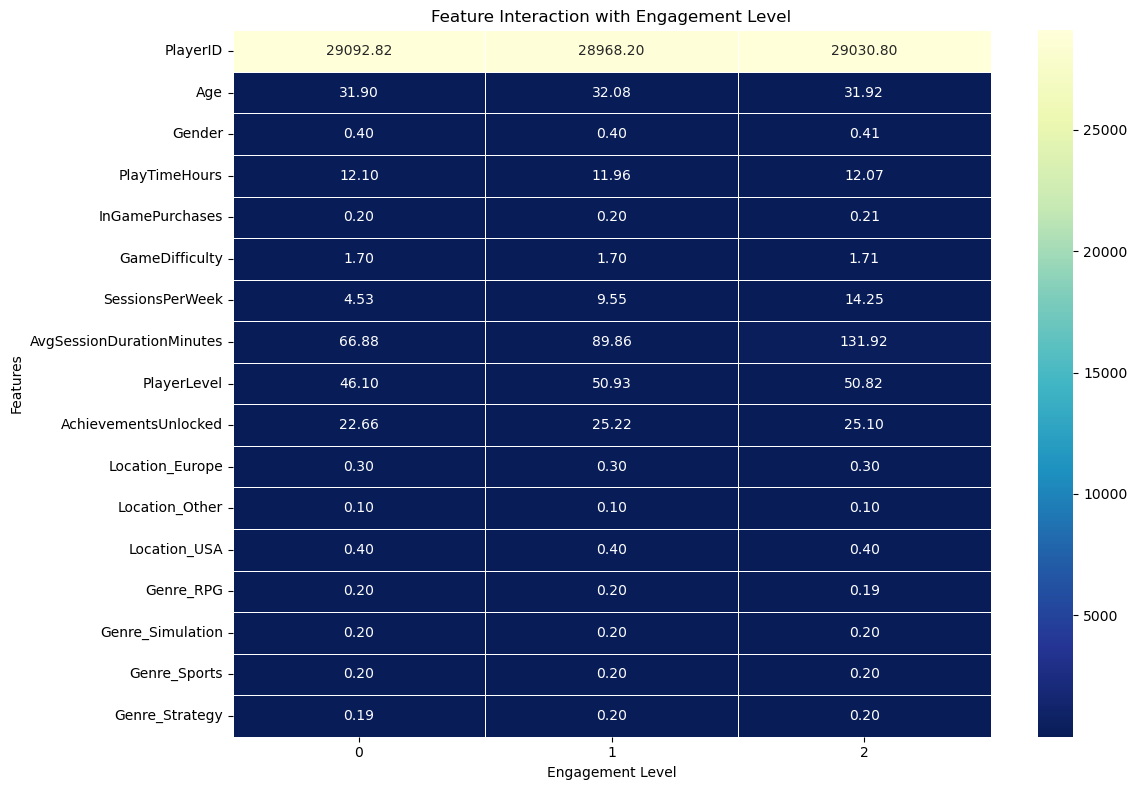

In [55]:
# Group by EngagementLevel and calculate mean values for features
engagement_correlation = encoded_data.groupby('EngagementLevel').mean().T

# Plot the heatmap for feature interaction with EngagementLevel
plt.figure(figsize=(12, 8))
sns.heatmap(
    engagement_correlation, 
    annot=True, 
    cmap='YlGnBu_r', 
    fmt='.2f', 
    linewidths=0.5, 
    cbar_kws={"shrink": 1}
)
plt.title('Feature Interaction with Engagement Level')
plt.ylabel('Features')
plt.xlabel('Engagement Level')
plt.tight_layout()
plt.show()


### **Key Observations:**
1. **Session Metrics (Frequency and Duration)**:
   - Strongly correlate with engagement levels.
   - High engagement players log more frequent and longer sessions.
2. **Player Progression (Level and Achievements)**:
   - High engagement players tend to progress further and unlock more achievements.
3. **Purchase Behavior**:
   - High engagement correlates with slightly higher in-game purchases.
4. **Genre and Difficulty Preferences**:
   - Strategy games and higher difficulties align with increased engagement.

### **Recommendations:**
1. **Boost Low and Medium Engagement:**
   - Introduce features like daily challenges or achievement-based incentives to increase session frequency.
2. **Encourage Player Progression:**
   - Provide level-based rewards and progression milestones to motivate gameplay.
3. **Enhance Game Design:**
   - Focus on challenging gameplay and strategy elements to retain highly engaged players.
4. **Optimize Monetization:**
   - Use personalized offers and exclusive in-game items to convert Medium engagement players to High engagement.
5. **Targeted Marketing:**
   - Focus on the USA market for maximum reach, while designing regional campaigns for Europe and Asia.

In [56]:
# Drop PlayerID as it's not a predictive feature
encoded_data = encoded_data.drop(columns=['PlayerID'])

In [57]:
# Define features and target
X = encoded_data.drop(columns=['EngagementLevel'])  # Features
y = encoded_data['EngagementLevel']  # Target

In [58]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the splits for verification
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")


Training Features Shape: (32027, 16)
Testing Features Shape: (8007, 16)
Training Target Shape: (32027,)
Testing Target Shape: (8007,)


In [59]:
# Apply Scaler to standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training and Evaluation

In [60]:
# Model Initialization
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight = 'balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42, n_jobs=1, class_weight = 'balanced')
}

# Display model names to confirm initialization
print("Models initialized:", list(models.keys()))

Models initialized: ['Random Forest', 'XGBoost', 'LightGBM']


Training and evaluating: Random Forest

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      2065
           1       0.91      0.95      0.93      3875
           2       0.93      0.88      0.90      2067

    accuracy                           0.91      8007
   macro avg       0.92      0.90      0.91      8007
weighted avg       0.92      0.91      0.91      8007



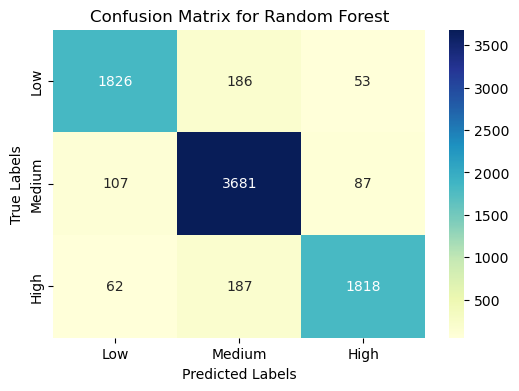

Training and evaluating: XGBoost

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      2065
           1       0.91      0.95      0.93      3875
           2       0.93      0.89      0.91      2067

    accuracy                           0.92      8007
   macro avg       0.92      0.91      0.91      8007
weighted avg       0.92      0.92      0.92      8007



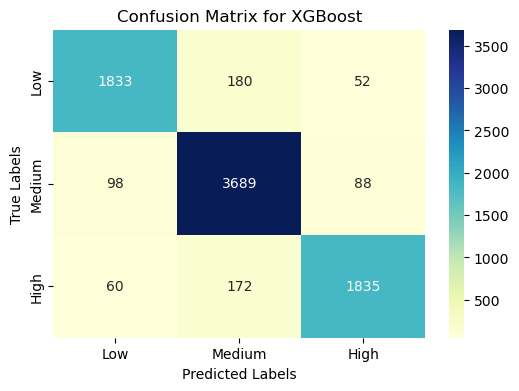

Training and evaluating: LightGBM

Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      2065
           1       0.92      0.93      0.93      3875
           2       0.92      0.89      0.91      2067

    accuracy                           0.91      8007
   macro avg       0.91      0.91      0.91      8007
weighted avg       0.91      0.91      0.91      8007



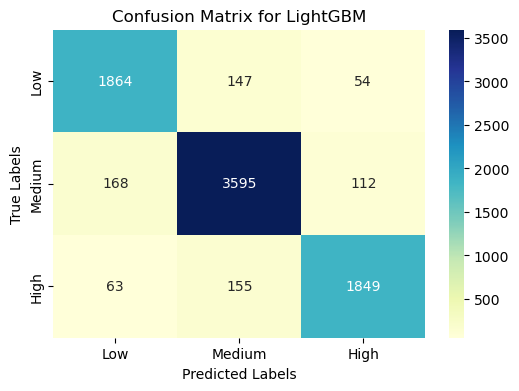


Summary of Model Evaluation:


,Model,Accuracy,AUC
0,XGBoost,0.918821,0.946141
1,Random Forest,0.914825,0.944123
2,LightGBM,0.912701,0.946413


In [61]:
# Initialize results storage
model_results = []

# Train and evaluate models
for model_name, model in models.items():
    print(f"Training and evaluating: {model_name}")
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate accuracy and AUC
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled), multi_class='ovr') if y_pred_proba is not None else None
    
    # Store results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc if auc else "N/A"
    })
    
    # Print classification report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

# Create a summary table of results
results_df = pd.DataFrame(model_results).sort_values(by="Accuracy", ascending=False)
results_df.reset_index(drop=True, inplace=True)

# Display the summary results
print("\nSummary of Model Evaluation:")
display(results_df)


## Model Evaluation Summary

### Overall Performance

| Model              | Accuracy | AUC    |
|-------------------|---------:|-------:|
| XGBoost           | **91.88%** | 0.9461 |
| Random Forest     | 91.48%   | 0.9441 |
| LightGBM          | 91.27%   | **0.9464** |

- **XGBoost** achieved the highest accuracy, making it the strongest overall performer.
- **LightGBM** recorded the highest AUC, indicating slightly better ranking capability.
- **Random Forest** remains a strong and reliable baseline but is marginally outperformed by boosting methods.
- All models perform within a narrow range, confirming strong signal in the dataset.

---

### Confusion Matrix Insights

- All models perform well in predicting **Medium engagement**, the dominant class.
- Minor misclassifications occur between adjacent segments (**High vs Medium**, **Low vs Medium**).
- Error distribution is low and consistent across all models.

---

### Classification Report Insights

- Precision, Recall, and F1-scores are **balanced across all engagement levels**.
- No significant class bias is observed.
- Boosting models (XGBoost, LightGBM) show slightly better consistency in classification performance.

---

### Key Takeaway

> **XGBoost emerges as the best overall model**, delivering the highest accuracy while maintaining strong AUC performance.  
> **LightGBM is a close alternative** for ranking-focused use cases, while **Random Forest serves as a solid benchmark model.**


The best model is: XGBoost




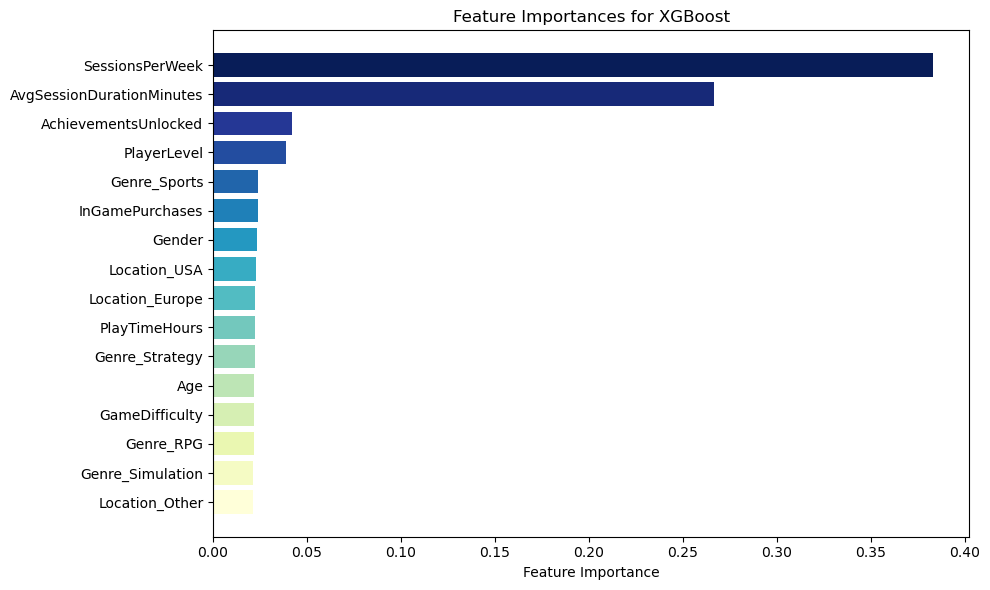

In [62]:
# Identify the best model based on the highest Accuracy
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), "Model"]
print(f"The best model is: {best_model_name}")
print("\n")

best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

# Plot feature importances 
if hasattr(best_model, "feature_importances_"):
    feature_importances = best_model.feature_importances_
    feature_names = X.columns

    # Plotting feature importances
    plt.figure(figsize=(10, 6))
    sorted_idx = feature_importances.argsort()[::-1]

    colors = plt.cm.YlGnBu_r(np.linspace(0, 1, len(feature_importances)))

    plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center', color=colors)
    plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
    plt.xlabel("Feature Importance")
    plt.title(f"Feature Importances for {best_model_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not support feature importances.")


### Insights from the Feature Importance Plot

1. **Dominant Features:**
   - **`SessionsPerWeek`**: The single most influential feature (~0.38) — session frequency is the strongest predictor of player engagement, reinforcing that consistent weekly habits matter more than any other behavioral signal.
   - **`AvgSessionDurationMinutes`**: A close second (~0.27) — longer individual sessions are a hallmark of highly engaged players. Together with `SessionsPerWeek`, these two features account for roughly 65% of the model's predictive power.

2. **Moderately Important Features:**
   - **`AchievementsUnlocked`** (~0.04) and **`PlayerLevel`** (~0.04): Progression mechanics carry meaningful but secondary weight. Players who level up and unlock achievements tend to stay more engaged, but the effect is much smaller than raw session behavior.

3. **Lower Importance Features:**
   - **`Genre_Sports`**, **`InGamePurchases`**, **`Gender`**, **`Location_USA`**, **`Location_Europe`**, **`PlayTimeHours`**, **`Genre_Strategy`** (~0.02 each): A cluster of demographic, monetization, and preference features all contributing roughly equally and modestly. None of them dominates the others.

4. **Negligible Features:**
   - **`Age`**, **`GameDifficulty`**, **`Genre_RPG`**, **`Genre_Simulation`**, **`Location_Other`**: These contribute almost nothing to the model's predictions. Age and difficulty in particular show that player engagement is driven by *behavior*, not *demographics* or *settings*.

### Key Takeaway

Engagement is fundamentally a **behavioral signal**, not a demographic or preference one. The model relies overwhelmingly on how often and how long players play, with progression metrics as a secondary layer. Demographics (age, gender, location) and game characteristics (genre, difficulty, monetization) are essentially background noise. This suggests that retention strategies should focus on **driving session frequency and duration** rather than targeting players based on who they are or what they play. a driver of it.